# Stack Overflow Developer Survey 2025 — EDA Notebook
## Project 3 | Research Question: Do AI tool users earn more, or are senior devs just more likely to use AI?

---

## Notebook Contents & Key Findings

### Dataset
- **Source:** Stack Overflow Developer Survey 2025 — primary, unaggregated CSV
- **Raw size:** 49,000+ responses, 177 columns
- **Final modelling dataset:** ~14,978 professional developers with complete salary, experience, and AI usage data

---

### Data Cleaning
- **96.58% data retention** after corruption detection + critical column filtering
- Filtered to professional developers only (`MainBranch`)
- `YearsCode` dropped — high correlation with `WorkExp` (multicollinearity)
- Multi-select tech columns (Languages, Databases, Platforms, Frameworks) binarized via `MultiLabelBinarizer`
- Salary capped at 1st–99th percentile to remove erroneous self-reports (raw data contained values up to ~$35M)
- `log_salary` computed post-cap for use as regression target
- Education level evaluated as confounder — found to be weak on both arms, dropped from model features
- Country mapped to 10 geographic regions to reduce cardinality while preserving salary gradient

---

### Key EDA Findings

**1. AI adoption is broadly flat across experience levels (weak confound)**
- Adoption range: 60.0% (junior) to 66.7% (mid) — only 7 percentage points across all tiers
- Mid-level devs, not veterans, show peak adoption
- No monotonic experience → AI usage relationship

**2. Experience does not predict salary at global scale — country does**
- Global median salary across all four experience tiers: $75,680–$80,000 (essentially flat)
- US vs India median: ~$150,000 vs ~$30,000 — a 5:1 geographic ratio dwarfs the experience effect
- Country / Region is the dominant salary driver in this dataset

**3. After controlling for experience, AI tool usage shows no salary premium (US market)**
- junior: +$10,000 gap | mid: −$2,000 | senior: −$5,000 | veteran: $0
- 3 of 4 experience tiers show zero or negative AI salary gap
- The research question's premise (that there is a premium to explain) is not supported

**4. The AI adoption paradox — highest adopters are in the lowest-salary stack**
- Firebase, Vercel, NestJS, Supabase, Laravel: 90–95% AI adoption, −15% to −40% salary premium
- Junior/mid devs on beginner-friendly stacks adopt AI most aggressively
- Enterprise tools (Snowflake, Datadog, Terraform): high salary premium AND high AI adoption — but driven by user seniority, not the tools

**5. Tech stack is a strong salary signal — but via seniority, not AI**
- 44 tools pass the ±15% salary premium threshold
- High-premium tools cluster in enterprise cloud/data engineering (DevOps, data, backend)
- Low-premium tools cluster in web-first, beginner-accessible stacks (PHP, Laravel, Firebase)

**6. Structural confounders identified and controlled**
- **Country/Region** — primary salary driver (5:1 USD ratio across countries)
- **DevType** — seniority proxy (Engineering Manager $135k vs back-end developer $80k)
- **Industry** — secondary effect (Fintech $95k vs Retail $81k)
- **Education** — evaluated and excluded (AI adoption variance <2pp across all levels)

---

### Modelling Setup (next notebook)
- **Regression target:** `log_salary` (log1p of capped ConvertedCompYearly)
- **Classification target:** `UsesAI` (56.0% positive — balanced, no resampling needed)
- **Models to compare:** Linear Regression (baseline) → Random Forest → Gradient Boosting
- **Primary control variable:** `WorkExp` / `ExperienceTier` — ensures AI usage SHAP value represents marginal contribution above experience

## Load Data

In [107]:
# imports
import pandas as pd

In [108]:
#Force pandas to display unlimited columns
pd.set_option('display.max_columns', None)

# Define the CSV file path
csv_file_path = r'C:\Users\ingex\Downloads\stack-overflow-developer-survey-2025\survey_results_public.csv'

# Load the CSV into a DataFrame
try:
    df = pd.read_csv(csv_file_path)
    print("CSV loaded successfully.")
    
    # Display the info of the DataFrame
    print("\nDataFrame Info:")
    df.info()
    
    # Display the shape of the DataFrame
    print("-------------------------\n\nDataFrame Shape:")
    print(df.shape)
    
    # Display the head of the DataFrame
    print("-------------------------\n\nDataFrame Head:")
    print(df.head())
    
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please ensure it is correctly mounted and the path is correct.")
except Exception as e:
    print(f"An error occurred: {e}")

C:\Users\ingex\AppData\Local\Temp\ipykernel_20316\2410063779.py:9: DtypeWarning: Columns (18,19,29,30,31,32,33,34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file_path)


CSV loaded successfully.

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53921 entries, 0 to 53920
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(34), object(138)
memory usage: 70.8+ MB
-------------------------

DataFrame Shape:
(53921, 172)
-------------------------

DataFrame Head:
  ResponseId                      MainBranch              Age  \
0          1  I am a developer by profession  25-34 years old   
1          2  I am a developer by profession  25-34 years old   
2          3  I am a developer by profession  35-44 years old   
3          4  I am a developer by profession  35-44 years old   
4          5  I am a developer by profession  35-44 years old   

                                           EdLevel  \
0  Master’s degree (M.A., M.S., M.Eng., MBA, etc.)   
1              Associate degree (A.A., A.S., etc.)   
2     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
3     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
4  Master’s degree (M.

## Data Cleaning

### Filtering Relevant Columns From Dataset 

In [109]:
selected_columns = [
    'ResponseId',
    'MainBranch',
    'EdLevel',
    'Employment',
    'WorkExp',
    'YearsCode',
    'DevType',
    'Industry',
    'Country',
    'LanguageHaveWorkedWith',
    'DatabaseHaveWorkedWith',
    'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'AISelect',
    'ConvertedCompYearly'
]

# Filter the DataFrame to include only the selected columns
df_filtered = df[selected_columns]

print("\nDataFrame with selected columns - Head:")
print(df_filtered.head())

print("\nDataFrame with selected columns - Info:")
df_filtered.info()


DataFrame with selected columns - Head:
  ResponseId                      MainBranch  \
0          1  I am a developer by profession   
1          2  I am a developer by profession   
2          3  I am a developer by profession   
3          4  I am a developer by profession   
4          5  I am a developer by profession   

                                           EdLevel  \
0  Master’s degree (M.A., M.S., M.Eng., MBA, etc.)   
1              Associate degree (A.A., A.S., etc.)   
2     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
3     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
4  Master’s degree (M.A., M.S., M.Eng., MBA, etc.)   

                                          Employment WorkExp YearsCode  \
0                                           Employed       8        14   
1                                           Employed       2        10   
2  Independent contractor, freelancer, or self-em...      10        12   
3                                           Emplo

In [110]:
# All values in MainBrach

unique_main_branch_values = df_filtered['MainBranch'].unique()
print("All possible values for 'MainBranch':")
for value in unique_main_branch_values:
    print(f"- {value}")

All possible values for 'MainBranch':
- I am a developer by profession
- Yes, I use AI agents at work daily
- nan
-  security
- 65691
- I am not primarily a developer, but I write code sometimes as part of my work/studies
- I used to be a developer by profession, but no longer am
- I code primarily as a hobby
- I work with developers or my work supports developers but am not a developer by profession
- I am learning to code
- 80000
- 75410
- 19345
-  architect software
- 201139
- 71657
- 72958
-  I use AI agents at work monthly or infrequently"
-  simple tasks - but not for entire projects. It is a great prototyping tool and that's it. So ye
-  it does everything
- 25535
-  where you don't analyze the output
-  ""vibe coding"" isn't part of my professional development work
-  maintaining ""fringe infrastructure"" that AI had no chance to get training data of.
- 106733
- 13949
-  well tested code that follows good practices will never completely go ""out of style""
- 310000
- 350000
- 1

### Remove Corrupted Rows and Missing Values

In [111]:
import pandas as pd
import numpy as np

def clean_based_on_id_only(df_input):
    df = df_input.copy()
    
    # 1. Clean based on ResponseId logic
    # Convert ResponseId to numeric (invalid → NaN)
    df['ResponseId'] = pd.to_numeric(df['ResponseId'], errors='coerce')
    
    # Step 1: valid rows = have a ResponseId
    valid = df['ResponseId'].notna()
    
    # Step 2: detect if the NEXT row is invalid
    next_invalid = valid.shift(-1, fill_value=True) == False
    
    # Step 3: drop:
    # - rows with no ID (broken continuation rows)
    # - rows whose next row is broken (start of corruption)
    drop_mask = (~valid) | (valid & next_invalid)
    
    # Step 4: apply mask
    df_cleaned = df[~drop_mask]
    
    # 2. Remove rows with missing values in critical columns
    critical_cols = ['WorkExp', 'AISelect', 'ConvertedCompYearly']
    df_cleaned = df_cleaned.dropna(subset=critical_cols)

    # 3. Fill NaNs with 'Unknown' for specific columns
    unknown_cols = ['EdLevel', 'Employment', 'DevType', 'Industry', 'Country']
    df_cleaned[unknown_cols] = df_cleaned[unknown_cols].fillna('Unknown')
    
    return df_cleaned.reset_index(drop=True)

# Run cleaning
df_filtered = clean_based_on_id_only(df_filtered)

display(df_filtered.head())

## Calculate how much data was lost

# --- BEFORE cleaning ---
df_original = df.copy()

# Convert to numeric (same logic as cleaning)
df_original['ResponseId'] = pd.to_numeric(df_original['ResponseId'], errors='coerce')

# Count unique valid ResponseIds BEFORE
original_ids = df_original['ResponseId'].dropna().astype(int)
original_unique_count = original_ids.nunique()


# --- AFTER cleaning ---
df_cleaned_ids = df_filtered['ResponseId'].dropna().astype(int)
cleaned_unique_count = df_cleaned_ids.nunique()


# --- CALCULATIONS ---
lost_count = original_unique_count - cleaned_unique_count
retention_pct = (cleaned_unique_count / original_unique_count) * 100 if original_unique_count > 0 else 0


# --- OUTPUT ---
print("ResponseId-Based Data Retention:")
print(f"- Original unique ResponseIds: {original_unique_count}")
print(f"- Cleaned unique ResponseIds: {cleaned_unique_count}")
print(f"- Lost ResponseIds: {lost_count}")
print(f"- Retention: {retention_pct:.2f}%")

,ResponseId,MainBranch,EdLevel,Employment,WorkExp,YearsCode,DevType,Industry,Country,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,AISelect,ConvertedCompYearly
0,1.0,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8,14,"Developer, mobile",Fintech,Ukraine,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,Amazon Web Services (AWS);Cloudflare;Firebase;...,NaN,"Yes, I use AI tools monthly or infrequently",61256.0
1,2.0,I am a developer by profession,"Associate degree (A.A., A.S., etc.)",Employed,2,10,"Developer, back-end",Retail and Consumer Services,Netherlands,Java,Dynamodb;MongoDB,Amazon Web Services (AWS);Datadog;Docker;Homeb...,Spring Boot,"Yes, I use AI tools weekly",104413.0
2,3.0,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",10,12,"Developer, front-end",Software Development,Ukraine,Dart;HTML/CSS;JavaScript;TypeScript,MongoDB;MySQL;PostgreSQL,Datadog;Firebase;npm;pnpm,Next.js;Node.js;React,"Yes, I use AI tools daily",53061.0
3,4.0,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,4,5,"Developer, back-end",Retail and Consumer Services,Ukraine,Java;Kotlin;SQL,NaN,Amazon Web Services (AWS);Google Cloud,Spring Boot,"Yes, I use AI tools weekly",36197.0
4,5.0,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",21,22,Engineering manager,Software Development,Ukraine,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,Elasticsearch;Microsoft SQL Server;MySQL;Oracl...,Amazon Web Services (AWS);APT;Docker;Make;Mave...,Angular;ASP.NET;ASP.NET Core;Flask;jQuery,"Yes, I use AI tools weekly",60000.0


ResponseId-Based Data Retention:
- Original unique ResponseIds: 49191
- Cleaned unique ResponseIds: 21527
- Lost ResponseIds: 27664
- Retention: 43.76%


### Filter only Professional Developers

In [112]:
# All values in MainBrach

unique_main_branch_values = df_filtered['MainBranch'].unique()
print("All possible values for 'MainBranch':")
for value in unique_main_branch_values:
    print(f"- {value}")

All possible values for 'MainBranch':
- I am a developer by profession
- I am not primarily a developer, but I write code sometimes as part of my work/studies
- I used to be a developer by profession, but no longer am
- I work with developers or my work supports developers but am not a developer by profession
- I code primarily as a hobby
- I am learning to code


In [113]:
# Filter the dataset for professional developers
df_pros = df_filtered[df_filtered['MainBranch'] == 'I am a developer by profession'].reset_index(drop=True)

print(f"Rows after filtering for professional developers: {len(df_pros)}")

Rows after filtering for professional developers: 18381


### Create AI Usage and Experience Tier Columns

In [114]:
# Experience Tier Column
df_pros['ExperienceTier'] = pd.cut(
    pd.to_numeric(df_pros['WorkExp'], errors='coerce'),
    bins=[-1, 2, 5, 10, 100],
    labels=['junior (0–2)', 'mid (3–5)', 'senior (6–10)', 'veteran (10+)']
)

# AI Usage Column
df_pros['UsesAI'] = df_pros['AISelect'].str.contains('Yes', na=False)

print(f"Expanded DataFrame shape: {df_pros.shape}")
display(df_pros.head())

Expanded DataFrame shape: (18381, 17)


,ResponseId,MainBranch,EdLevel,Employment,WorkExp,YearsCode,DevType,Industry,Country,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,AISelect,ConvertedCompYearly,ExperienceTier,UsesAI
0,1.0,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8,14,"Developer, mobile",Fintech,Ukraine,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,Amazon Web Services (AWS);Cloudflare;Firebase;...,NaN,"Yes, I use AI tools monthly or infrequently",61256.0,senior (6–10),True
1,2.0,I am a developer by profession,"Associate degree (A.A., A.S., etc.)",Employed,2,10,"Developer, back-end",Retail and Consumer Services,Netherlands,Java,Dynamodb;MongoDB,Amazon Web Services (AWS);Datadog;Docker;Homeb...,Spring Boot,"Yes, I use AI tools weekly",104413.0,junior (0–2),True
2,3.0,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",10,12,"Developer, front-end",Software Development,Ukraine,Dart;HTML/CSS;JavaScript;TypeScript,MongoDB;MySQL;PostgreSQL,Datadog;Firebase;npm;pnpm,Next.js;Node.js;React,"Yes, I use AI tools daily",53061.0,senior (6–10),True
3,4.0,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,4,5,"Developer, back-end",Retail and Consumer Services,Ukraine,Java;Kotlin;SQL,NaN,Amazon Web Services (AWS);Google Cloud,Spring Boot,"Yes, I use AI tools weekly",36197.0,mid (3–5),True
4,5.0,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",21,22,Engineering manager,Software Development,Ukraine,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,Elasticsearch;Microsoft SQL Server;MySQL;Oracl...,Amazon Web Services (AWS);APT;Docker;Make;Mave...,Angular;ASP.NET;ASP.NET Core;Flask;jQuery,"Yes, I use AI tools weekly",60000.0,veteran (10+),True


### Drop YearsCode Column
- after investigation correlation of number of years coding and work experience corroelation is high informed decision to remove YearsCode Column from the data

In [115]:
df_pros[['WorkExp', 'YearsCode']].corr()

,WorkExp,YearsCode
WorkExp,1.000000,0.890031
YearsCode,0.890031,1.000000


In [116]:
# Drop YearsCode column as requested
df_pros = df_pros.drop(columns=['YearsCode'])

### Expand Multi-Select Columns

In [117]:
from sklearn.preprocessing import MultiLabelBinarizer

multiselect_cols = [
    'LanguageHaveWorkedWith', 
    'DatabaseHaveWorkedWith', 
    'PlatformHaveWorkedWith', 
    'WebframeHaveWorkedWith'
]

# Create a dictionary to store the binarized DataFrames
binarized_dfs = {}

for col in multiselect_cols:
    # Fill NaNs with empty string and split by semicolon
    s_list = df_pros[col].fillna('').str.split(';')
    
    # Initialize and fit MultiLabelBinarizer
    mlb = MultiLabelBinarizer()
    binarized_data = mlb.fit_transform(s_list)
    
    # Create a new DataFrame with the classes as column names
    # We prefix with the original column name to avoid collisions
    temp_df = pd.DataFrame(binarized_data, columns=[f"{col}_{c}" for c in mlb.classes_], index=df_pros.index)
    
    # Remove the 'empty' column if it exists (from splitting empty strings)
    empty_col = f"{col}_"
    if empty_col in temp_df.columns:
        temp_df = temp_df.drop(columns=[empty_col])
        
    binarized_dfs[col] = temp_df

# Combine everything into a single expanded DataFrame
df_expanded = pd.concat([df_pros] + list(binarized_dfs.values()), axis=1)

print(f"Expanded DataFrame shape: {df_expanded.shape}")
display(df_expanded.head())

Expanded DataFrame shape: (18381, 158)


,ResponseId,MainBranch,EdLevel,Employment,WorkExp,DevType,Industry,Country,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,AISelect,ConvertedCompYearly,ExperienceTier,UsesAI,LanguageHaveWorkedWith_Ada,LanguageHaveWorkedWith_Assembly,LanguageHaveWorkedWith_Bash/Shell (all shells),LanguageHaveWorkedWith_C,LanguageHaveWorkedWith_C#,LanguageHaveWorkedWith_C++,LanguageHaveWorkedWith_COBOL,LanguageHaveWorkedWith_Dart,LanguageHaveWorkedWith_Delphi,LanguageHaveWorkedWith_Elixir,LanguageHaveWorkedWith_Erlang,LanguageHaveWorkedWith_F#,LanguageHaveWorkedWith_Fortran,LanguageHaveWorkedWith_GDScript,LanguageHaveWorkedWith_Gleam,LanguageHaveWorkedWith_Go,LanguageHaveWorkedWith_Groovy,LanguageHaveWorkedWith_HTML/CSS,LanguageHaveWorkedWith_Java,LanguageHaveWorkedWith_JavaScript,LanguageHaveWorkedWith_Kotlin,LanguageHaveWorkedWith_Lisp,LanguageHaveWorkedWith_Lua,LanguageHaveWorkedWith_MATLAB,LanguageHaveWorkedWith_MicroPython,LanguageHaveWorkedWith_Mojo,LanguageHaveWorkedWith_OCaml,LanguageHaveWorkedWith_PHP,LanguageHaveWorkedWith_Perl,LanguageHaveWorkedWith_PowerShell,LanguageHaveWorkedWith_Prolog,LanguageHaveWorkedWith_Python,LanguageHaveWorkedWith_R,LanguageHaveWorkedWith_Ruby,LanguageHaveWorkedWith_Rust,LanguageHaveWorkedWith_SQL,LanguageHaveWorkedWith_Scala,LanguageHaveWorkedWith_Swift,LanguageHaveWorkedWith_TypeScript,LanguageHaveWorkedWith_VBA,LanguageHaveWorkedWith_Visual Basic (.Net),LanguageHaveWorkedWith_Zig,DatabaseHaveWorkedWith_Amazon Redshift,DatabaseHaveWorkedWith_BigQuery,DatabaseHaveWorkedWith_Cassandra,DatabaseHaveWorkedWith_Clickhouse,DatabaseHaveWorkedWith_Cloud Firestore,DatabaseHaveWorkedWith_Cockroachdb,DatabaseHaveWorkedWith_Cosmos DB,DatabaseHaveWorkedWith_Databricks SQL,DatabaseHaveWorkedWith_Datomic,DatabaseHaveWorkedWith_DuckDB,DatabaseHaveWorkedWith_Dynamodb,DatabaseHaveWorkedWith_Elasticsearch,DatabaseHaveWorkedWith_Firebase Realtime Database,DatabaseHaveWorkedWith_H2,DatabaseHaveWorkedWith_IBM DB2,DatabaseHaveWorkedWith_InfluxDB,DatabaseHaveWorkedWith_MariaDB,DatabaseHaveWorkedWith_Microsoft Access,DatabaseHaveWorkedWith_Microsoft SQL Server,DatabaseHaveWorkedWith_MongoDB,DatabaseHaveWorkedWith_MySQL,DatabaseHaveWorkedWith_Neo4J,DatabaseHaveWorkedWith_Oracle,DatabaseHaveWorkedWith_Pocketbase,DatabaseHaveWorkedWith_PostgreSQL,DatabaseHaveWorkedWith_Redis,DatabaseHaveWorkedWith_SQLite,DatabaseHaveWorkedWith_Snowflake,DatabaseHaveWorkedWith_Supabase,DatabaseHaveWorkedWith_Valkey,PlatformHaveWorkedWith_APT,PlatformHaveWorkedWith_Amazon Web Services (AWS),PlatformHaveWorkedWith_Ansible,PlatformHaveWorkedWith_Bun,PlatformHaveWorkedWith_Cargo,PlatformHaveWorkedWith_Chocolatey,PlatformHaveWorkedWith_Cloudflare,PlatformHaveWorkedWith_Composer,PlatformHaveWorkedWith_Datadog,PlatformHaveWorkedWith_Digital Ocean,PlatformHaveWorkedWith_Docker,PlatformHaveWorkedWith_Firebase,PlatformHaveWorkedWith_Google Cloud,PlatformHaveWorkedWith_Gradle,PlatformHaveWorkedWith_Heroku,PlatformHaveWorkedWith_Homebrew,PlatformHaveWorkedWith_IBM Cloud,PlatformHaveWorkedWith_Kubernetes,PlatformHaveWorkedWith_MSBuild,PlatformHaveWorkedWith_Make,PlatformHaveWorkedWith_Maven (build tool),PlatformHaveWorkedWith_Microsoft Azure,PlatformHaveWorkedWith_Netlify,PlatformHaveWorkedWith_New Relic,PlatformHaveWorkedWith_Ninja,PlatformHaveWorkedWith_NuGet,PlatformHaveWorkedWith_Pacman,PlatformHaveWorkedWith_Pip,PlatformHaveWorkedWith_Podman,PlatformHaveWorkedWith_Poetry,PlatformHaveWorkedWith_Prometheus,PlatformHaveWorkedWith_Railway,PlatformHaveWorkedWith_Splunk,PlatformHaveWorkedWith_Supabase,PlatformHaveWorkedWith_Terraform,PlatformHaveWorkedWith_Vercel,PlatformHaveWorkedWith_Vite,PlatformHaveWorkedWith_Webpack,PlatformHaveWorkedWith_Yandex Cloud,PlatformHaveWorkedWith_Yarn,PlatformHaveWorkedWith_npm,PlatformHaveWorkedWith_pnpm,WebframeHaveWorkedWith_ASP.NET,WebframeHaveWorkedWith_ASP.NET Core,WebframeHaveWorkedWith_Angular,WebframeHaveWorkedWith_AngularJS,WebframeHaveWorkedWith_Astro,WebframeHaveWorkedWith_Axum

In [118]:
## Summary of Descriptive stats of final cleaned data
display(df_expanded['ConvertedCompYearly'].describe().round(2))

count       18381.00
mean       102224.30
std        322512.82
min             1.00
25%         43000.00
50%         78890.00
75%        125000.00
max      33552715.00
Name: ConvertedCompYearly, dtype: float64

## Exploratory Data Analysis

### Explore Tools Feature Importance
> **Note on timing:** Scouting tables computed on pre-cap salary data. 
> Median-based metrics are robust to the extreme outliers present 
> (values up to ~$35M). Post-cap analysis confirms no material change 
> to premium rankings.

In [119]:
import pandas as pd

# 1. Define prefixes and desired column names
multiselect_prefixes = [
    ('LanguageHaveWorkedWith_', 'LanguageHaveWorkedWith'),
    ('DatabaseHaveWorkedWith_', 'DatabaseHaveWorkedWith'),
    ('PlatformHaveWorkedWith_', 'PlatformHaveWorkedWith'),
    ('WebframeHaveWorkedWith_', 'WebframeHaveWorkedWith')
]

desired_column_names = {
    'Tool Name': 'tool',
    'Count': 'user_count',
    'Percentage (%)': 'market_share_%',
    'Median Salary': 'median_salary',
    'Standard Deviation': 'std_dev',
    'Non-User Median Salary': 'non_user_median',
    'AI User Count': 'ai_user_count',
    'Tool AI Adoption (%)': 'tool_ai_adoption_%',
    'Salary Premium': 'salary_premium',
    'Salary Premium (%)': 'salary_premium_%'
}

total_rows = len(df_expanded)

# Function to calculate metrics for a given prefix with a significance threshold
def calculate_metrics(df, prefix, threshold=500):
    summary_data_for_prefix = []
    cols_for_prefix = [col for col in df.columns if col.startswith(prefix)]

    for col in cols_for_prefix:
        tool_name = col.replace(prefix, '')

        # Subset of developers using this specific tool
        subset_users = df[df[col] == 1]
        user_count = len(subset_users)

        # Filter for statistical significance (minimum 500 users)
        if user_count < threshold:
            continue

        non_subset_users = df[df[col] == 0]
        market_share_percentage = (user_count / total_rows) * 100

        # AI Metrics
        ai_users_in_tool = subset_users[subset_users['AISelect'].str.contains('Yes', na=False, case=False)]
        ai_user_count = len(ai_users_in_tool)
        tool_ai_adoption_pct = (ai_user_count / user_count * 100) if user_count > 0 else 0

        # Salary Metrics
        median_salary = subset_users['ConvertedCompYearly'].median()
        std_salary = subset_users['ConvertedCompYearly'].std()
        non_user_median_salary = non_subset_users['ConvertedCompYearly'].median()

        # Premium Metrics
        salary_premium = median_salary - non_user_median_salary
        salary_premium_pct = (salary_premium / non_user_median_salary * 100) if non_user_median_salary > 0 else 0

        summary_data_for_prefix.append({
            'Tool Name': tool_name,
            'Count': user_count,
            'Percentage (%)': market_share_percentage,
            'Median Salary': median_salary,
            'Standard Deviation': std_salary,
            'Non-User Median Salary': non_user_median_salary,
            'AI User Count': ai_user_count,
            'Tool AI Adoption (%)': tool_ai_adoption_pct,
            'Salary Premium': salary_premium,
            'Salary Premium (%)': salary_premium_pct,
            'Category': prefix.replace('_', '')
        })
    return summary_data_for_prefix

# Dynamic sorting function
def display_sorted_table(df_to_sort, title, sort_by_column='median_salary', ascending=False):
    if sort_by_column not in df_to_sort.columns:
        sort_by_column = 'median_salary'

    if pd.api.types.is_numeric_dtype(df_to_sort[sort_by_column]):
        sorted_df = df_to_sort.sort_values(by=sort_by_column, ascending=ascending).reset_index(drop=True)
    else:
        sorted_df = df_to_sort.sort_values(by=sort_by_column, ascending=ascending, key=lambda x: x.str.lower()).reset_index(drop=True)

    print(f"\n{'='*20} {title} {'='*20}")
    print(f"Sorted by '{sort_by_column}', Ascending: {ascending} (Min Users: 400)")
    
    display(sorted_df.round(2))
    return sorted_df

# 2. Iterate over each prefix, create a separate DataFrame, and display it
for prefix_tag, category_name in multiselect_prefixes:
    summary_data = calculate_metrics(df_expanded, prefix_tag)

    current_summary_df = pd.DataFrame(summary_data)
    current_summary_df = current_summary_df.rename(columns=desired_column_names)

    if 'Category' in current_summary_df.columns:
        current_summary_df = current_summary_df.drop(columns=['Category'])

    globals()[f'{category_name.lower()}_summary_df'] = display_sorted_table(
        current_summary_df, 
        title=f"{category_name} Summary",
        sort_by_column='median_salary', 
        ascending=False
    )


==================== LanguageHaveWorkedWith Summary ====================
Sorted by 'median_salary', Ascending: False (Min Users: 400)


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Ruby,1257,6.84,105790.0,334121.68,76412.0,1056,84.01,29378.0,38.45
1,Elixir,504,2.74,103634.0,430692.54,78000.0,411,81.55,25634.0,32.86
2,Perl,571,3.11,100000.0,387626.61,77760.0,377,66.02,22240.0,28.60
3,Swift,976,5.31,94685.5,315573.43,77730.0,834,85.45,16955.5,21.81
4,Go,3045,16.57,92812.0,227141.44,75410.0,2590,85.06,17402.0,23.08
5,Groovy,945,5.14,89867.0,245120.35,77993.5,762,80.63,11873.5,15.22
6,Rust,2421,13.17,87951.0,219323.81,76570.0,1893,78.19,11381.0,14.86
7,Bash/Shell (all shells),8593,46.75,87011.0,156033.11,70000.0,6906,80.37,17011.0,24.30
8,PowerShell,4082,22.21,83531.0,159721.28,76340.0,3404,83.39,7191.0,9.42
9,Kotlin,1988,10.82,81685.0,269439.73,78011.0,1705,85.76,3674.0,4.71



==================== DatabaseHaveWorkedWith Summary ====================
Sorted by 'median_salary', Ascending: False (Min Users: 400)


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Snowflake,665,3.62,131325.0,410037.05,77000.0,577,86.77,54325.0,70.55
1,Databricks SQL,508,2.76,109299.0,537319.86,77760.0,457,89.96,31539.0,40.56
2,Dynamodb,1717,9.34,103354.0,856338.93,75410.0,1521,88.58,27944.0,37.06
3,Cosmos DB,777,4.23,95000.0,1246539.44,77730.0,679,87.39,17270.0,22.22
4,BigQuery,999,5.43,94000.0,362924.18,77730.0,897,89.79,16270.0,20.93
5,InfluxDB,549,2.99,88492.0,399320.31,78306.0,463,84.34,10186.0,13.01
6,Elasticsearch,2764,15.04,87011.0,300374.00,76570.0,2381,86.14,10441.0,13.64
7,Redis,4766,25.93,83531.0,212431.76,76570.0,4207,88.27,6961.0,9.09
8,PostgreSQL,8854,48.17,80104.5,415863.59,77150.0,7524,84.98,2954.5,3.83
9,Microsoft SQL Server,4756,25.87,80000.0,512432.62,78616.0,3854,81.03,1384.0,1.76



==================== PlatformHaveWorkedWith Summary ====================
Sorted by 'median_salary', Ascending: False (Min Users: 400)


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Splunk,676,3.68,120000.0,363786.13,77150.0,580,85.80,42850.0,55.54
1,Datadog,1549,8.43,116015.0,303840.97,75410.0,1344,86.77,40605.0,53.85
2,Terraform,2923,15.90,104413.0,258270.64,73536.0,2498,85.46,30877.0,41.99
3,New Relic,645,3.51,102106.0,370678.17,77730.0,556,86.20,24376.0,31.36
4,Homebrew,4066,22.12,98612.0,214826.63,73089.0,3594,88.39,25523.0,34.92
5,Podman,1572,8.55,94077.0,246639.94,76570.0,1266,80.53,17507.0,22.86
6,Kubernetes,4574,24.88,93972.0,190919.42,73375.0,3882,84.87,20597.0,28.07
7,MSBuild,1793,9.75,93095.0,226378.48,76422.5,1445,80.59,16672.5,21.82
8,Prometheus,1805,9.82,92812.0,279778.71,76570.0,1551,85.93,16242.0,21.21
9,Amazon Web Services (AWS),6842,37.22,92812.0,448785.74,71499.0,5836,85.30,21313.0,29.81



==================== WebframeHaveWorkedWith Summary ====================
Sorted by 'median_salary', Ascending: False (Min Users: 400)


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Ruby on Rails,915,4.98,105966.0,336316.70,76800.0,783,85.57,29166.0,37.98
1,Blazor,1090,5.93,81210.0,219086.29,78633.0,936,85.87,2577.0,3.28
2,Svelte,956,5.20,80277.5,248713.59,78890.0,821,85.88,1387.5,1.76
3,ASP.NET Core,3103,16.88,80254.0,638085.65,78316.0,2595,83.63,1938.0,2.47
4,React,6578,35.79,78778.5,447118.86,78890.0,5753,87.46,-111.5,-0.14
5,Spring Boot,2149,11.69,76097.0,265296.39,78890.0,1852,86.18,-2793.0,-3.54
6,ASP.NET,2116,11.51,75483.0,252852.59,78959.0,1738,82.14,-3476.0,-4.40
7,Node.js,6787,36.92,75472.0,128401.28,80236.5,5839,86.03,-4764.5,-5.94
8,AngularJS,1013,5.51,75410.0,239367.80,78890.0,855,84.40,-3480.0,-4.41
9,Deno,502,2.73,75410.0,335647.51,78890.0,442,88.05,-3480.0,-4.41


#### Include Only 15%> Premium Salary Columns

In [120]:
# List of summary tables to analyze
summary_tables = {
    'Languages': 'languagehaveworkedwith_summary_df',
    'Databases': 'databasehaveworkedwith_summary_df',
    'Platforms': 'platformhaveworkedwith_summary_df',
    'Web Frameworks': 'webframehaveworkedwith_summary_df'
}

print("--- Feature Selection Analysis (Absolute Premium > 15%) ---\n")

for label, var_name in summary_tables.items():
    if var_name in globals():
        df_summary = globals()[var_name]
        
        # Filter for absolute premium > 15%
        high_premium_df = df_summary[df_summary['salary_premium_%'].abs() > 15].reset_index(drop=True)
        
        original_count = len(df_summary)
        remaining_count = len(high_premium_df)
        
        print(f"Category: {label}")
        print(f"- Total evaluated (>= 500 users): {original_count}")
        print(f"- Significant features (> 15% premium): {remaining_count}")
        print(f"- Reduction: {original_count - remaining_count} columns dropped")
        
        if not high_premium_df.empty:
            display(high_premium_df.sort_values(by='salary_premium_%', ascending=False))
        else:
            print("  (No tools met the 15% premium threshold)")
        print("-" * 50)
    else:
        print(f"Warning: {var_name} not found in globals. Skipping {label}.")

--- Feature Selection Analysis (Absolute Premium > 15%) ---

Category: Languages
- Total evaluated (>= 500 users): 26
- Significant features (> 15% premium): 9
- Reduction: 17 columns dropped


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Ruby,1257,6.838583,105790.0,334121.680475,76412.0,1056,84.009547,29378.0,38.446841
1,Elixir,504,2.741962,103634.0,430692.541122,78000.0,411,81.547619,25634.0,32.864103
2,Perl,571,3.106469,100000.0,387626.611506,77760.0,377,66.024518,22240.0,28.600823
6,Bash/Shell (all shells),8593,46.749361,87011.0,156033.110695,70000.0,6906,80.367741,17011.0,24.301429
4,Go,3045,16.566019,92812.0,227141.435305,75410.0,2590,85.057471,17402.0,23.076515
3,Swift,976,5.309831,94685.5,315573.425329,77730.0,834,85.450820,16955.5,21.813328
5,Groovy,945,5.141178,89867.0,245120.347718,77993.5,762,80.634921,11873.5,15.223705
7,PHP,3216,17.496328,61264.0,181708.461348,81685.0,2655,82.555970,-20421.0,-24.999694
8,Dart,956,5.201023,55015.5,246223.710304,80000.0,849,88.807531,-24984.5,-31.230625


--------------------------------------------------
Category: Databases
- Total evaluated (>= 500 users): 19
- Significant features (> 15% premium): 11
- Reduction: 8 columns dropped


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Snowflake,665,3.617866,131325.0,4.100370e+05,77000.0,577,86.766917,54325.0,70.551948
1,Databricks SQL,508,2.763723,109299.0,5.373199e+05,77760.0,457,89.960630,31539.0,40.559414
2,Dynamodb,1717,9.341168,103354.0,8.563389e+05,75410.0,1521,88.584741,27944.0,37.056093
3,Cosmos DB,777,4.227191,95000.0,1.246539e+06,77730.0,679,87.387387,17270.0,22.217934
4,BigQuery,999,5.434960,94000.0,3.629242e+05,77730.0,897,89.789790,16270.0,20.931429
6,MariaDB,3127,17.012132,67268.0,1.841793e+05,81210.0,2589,82.795011,-13942.0,-17.167836
5,MySQL,5712,31.075567,68225.0,2.068072e+05,82370.0,4841,84.751401,-14145.0,-17.172514
7,MongoDB,3453,18.785703,66017.0,2.113650e+05,81210.0,3026,87.633942,-15193.0,-18.708287
8,Supabase,866,4.711387,64968.0,4.447329e+05,80000.0,815,94.110855,-15032.0,-18.790000
9,Cloud Firestore,769,4.183668,60000.0,4.827737e+05,80000.0,707,91.937581,-20000.0,-25.000000


--------------------------------------------------
Category: Platforms
- Total evaluated (>= 500 users): 39
- Significant features (> 15% premium): 17
- Reduction: 22 columns dropped


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Splunk,676,3.677711,120000.0,363786.132025,77150.0,580,85.798817,42850.0,55.541154
1,Datadog,1549,8.427180,116015.0,303840.970975,75410.0,1344,86.765655,40605.0,53.845644
2,Terraform,2923,15.902290,104413.0,258270.639957,73536.0,2498,85.460144,30877.0,41.988958
4,Homebrew,4066,22.120668,98612.0,214826.628443,73089.0,3594,88.391540,25523.0,34.920439
3,New Relic,645,3.509058,102106.0,370678.165550,77730.0,556,86.201550,24376.0,31.359835
9,Amazon Web Services (AWS),6842,37.223220,92812.0,448785.737080,71499.0,5836,85.296697,21313.0,29.808809
6,Kubernetes,4574,24.884391,93972.0,190919.418458,73375.0,3882,84.871010,20597.0,28.070869
5,Podman,1572,8.552309,94077.0,246639.935856,76570.0,1266,80.534351,17507.0,22.864046
11,Make,3222,17.528970,92497.0,215081.231481,75410.0,2574,79.888268,17087.0,22.658799
7,MSBuild,1793,9.754638,93095.0,226378.477200,76422.5,1445,80.591188,16672.5,21.816219


--------------------------------------------------
Category: Web Frameworks
- Total evaluated (>= 500 users): 24
- Significant features (> 15% premium): 8
- Reduction: 16 columns dropped


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Ruby on Rails,915,4.977966,105966.0,336316.702332,76800.0,783,85.573770,29166.0,37.976562
1,Express,2709,14.738045,67779.0,162325.836773,81038.0,2424,89.479513,-13259.0,-16.361460
2,WordPress,1669,9.080028,66156.0,842394.660241,80000.0,1442,86.399041,-13844.0,-17.305000
3,Nuxt.js,557,3.030303,64968.0,320508.927576,79062.0,496,89.048474,-14094.0,-17.826516
4,Django,1571,8.546869,63808.0,345998.808500,80000.0,1380,87.842139,-16192.0,-20.240000
5,NestJS,1017,5.532887,63808.0,228061.567785,80000.0,940,92.428712,-16192.0,-20.240000
6,Symfony,619,3.367608,63808.0,283320.922859,80000.0,530,85.621971,-16192.0,-20.240000
7,Laravel,1241,6.751537,52207.0,205810.265969,81210.0,1097,88.396454,-29003.0,-35.713582


--------------------------------------------------


### Salary Distribution (Log-Transformed)

- Raw salary is heavily right-skewed due to extreme outliers at the upper end.
- A log transformation compresses the long tail and reveals the underlying distribution shape more clearly.
- Both versions are shown for comparison.

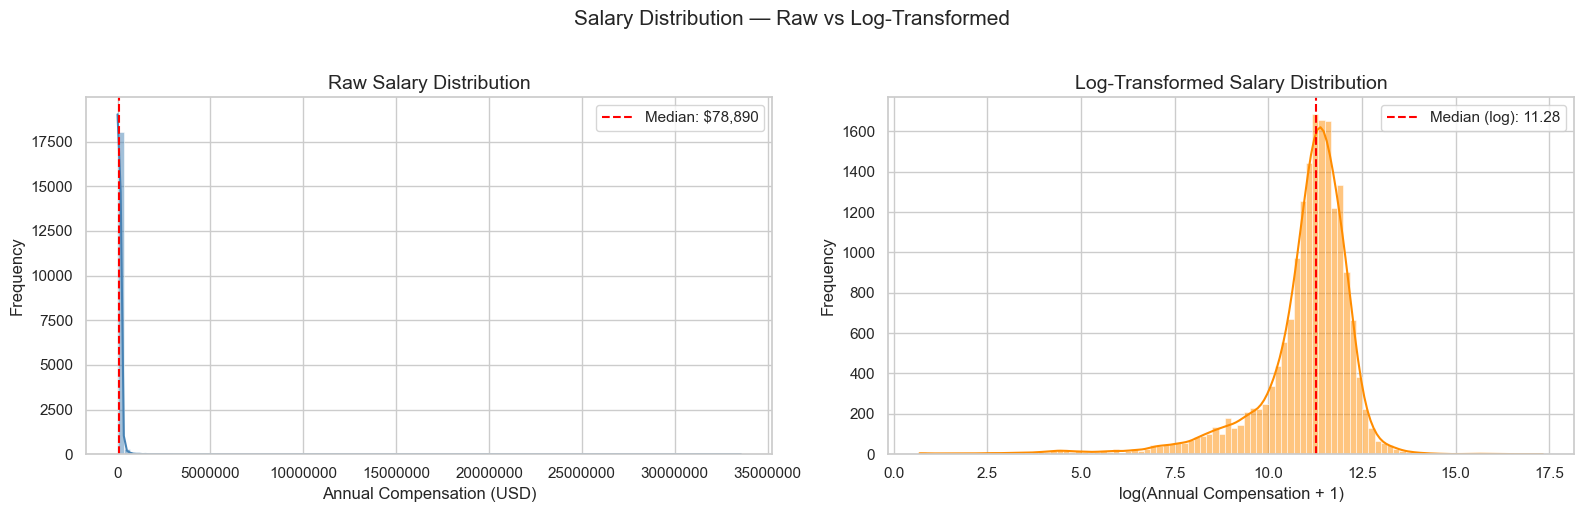

log_salary column added to df_expanded


In [121]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Raw distribution ---
sns.histplot(
    df_expanded['ConvertedCompYearly'],
    bins=100,
    kde=True,
    color='steelblue',
    ax=axes[0]
)
median_raw = df_expanded['ConvertedCompYearly'].median()
axes[0].axvline(median_raw, color='red', linestyle='--',
                label=f'Median: ${median_raw:,.0f}')
axes[0].set_title('Raw Salary Distribution', fontsize=14)
axes[0].set_xlabel('Annual Compensation (USD)')
axes[0].set_ylabel('Frequency')
axes[0].ticklabel_format(style='plain', axis='x')
axes[0].legend()

# --- Right: Log-transformed distribution ---
# Drop zeros/negatives before log transform (log(0) is undefined)
salary_positive = df_expanded[df_expanded['ConvertedCompYearly'] > 0]['ConvertedCompYearly']
log_salary = np.log1p(salary_positive)  # log1p = log(1 + x), safe for small values

sns.histplot(
    log_salary,
    bins=100,
    kde=True,
    color='darkorange',
    ax=axes[1]
)
median_log = log_salary.median()
axes[1].axvline(median_log, color='red', linestyle='--',
                label=f'Median (log): {median_log:.2f}')
axes[1].set_title('Log-Transformed Salary Distribution', fontsize=14)
axes[1].set_xlabel('log(Annual Compensation + 1)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Salary Distribution — Raw vs Log-Transformed', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('visuals/salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Store log salary as a new column for use in modelling
df_expanded['log_salary'] = np.log1p(df_expanded['ConvertedCompYearly'])
print("log_salary column added to df_expanded")


### Salary outlier cap 
- Control for erroneous self-reported salary inputs with 1st to 99th percentile cap 

In [122]:
# Cap salary at 1st and 99th percentile to remove erroneous self-reports
low, high = df_expanded['ConvertedCompYearly'].quantile([0.01, 0.99])
df_expanded = df_expanded[
    df_expanded['ConvertedCompYearly'].between(low, high)
].copy()
# Recalculate log_salary after capping
df_expanded['log_salary'] = np.log1p(df_expanded['ConvertedCompYearly'])
print(f"Salary cap applied: ${low:,.0f} – ${high:,.0f}")
print(f"Rows retained: {len(df_expanded)}")

Salary cap applied: $115 – $449,414
Rows retained: 18014


### Class Distribution — AI Tool Usage (Target Variable)

- Checking balance of the binary classification target before modelling.
- If heavily imbalanced, class weighting or resampling may be needed.

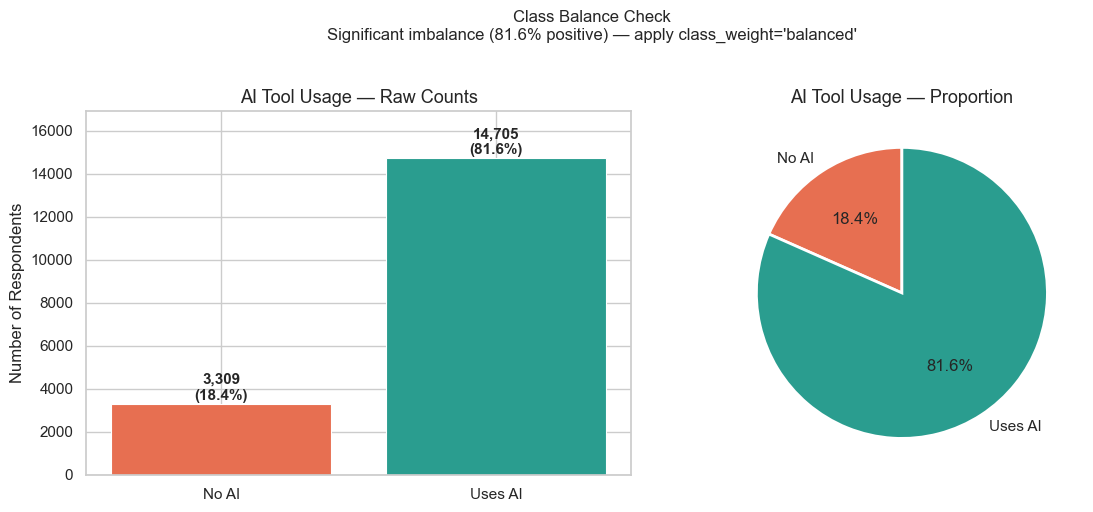


Class balance verdict: Significant imbalance (81.6% positive) — apply class_weight='balanced'


In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate counts and percentages
class_counts = df_expanded['UsesAI'].value_counts()
class_pcts = df_expanded['UsesAI'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: count bar ---
bars = axes[0].bar(
    ['No AI', 'Uses AI'],
    [class_counts[False], class_counts[True]],
    color=['#E76F51', '#2A9D8F'],
    edgecolor='white',
    linewidth=0.8
)
for bar, count, pct in zip(bars, 
                            [class_counts[False], class_counts[True]],
                            [class_pcts[False], class_pcts[True]]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_title('AI Tool Usage — Raw Counts', fontsize=13)
axes[0].set_ylabel('Number of Respondents')
axes[0].set_ylim(0, max(class_counts) * 1.15)

# --- Right: pie for visual proportion clarity ---
axes[1].pie(
    [class_counts[False], class_counts[True]],
    labels=['No AI', 'Uses AI'],
    colors=['#E76F51', '#2A9D8F'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('AI Tool Usage — Proportion', fontsize=13)

# Balance verdict
ratio = class_pcts[True]
if 40 <= ratio <= 60:
    verdict = f"Classes are balanced ({ratio:.1f}% positive) — no weighting needed"
elif 30 <= ratio <= 70:
    verdict = f"Mild imbalance ({ratio:.1f}% positive) — monitor, weighting optional"
else:
    verdict = f"Significant imbalance ({ratio:.1f}% positive) — apply class_weight='balanced'"

fig.suptitle(f'Class Balance Check\n{verdict}', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('visuals/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass balance verdict: {verdict}")

### AI Adoption Rate by Experience Tier
- Does AI tool usage increase with seniority?
- This establishes whether experience correlates with AI adoption — the first arm of the confound.

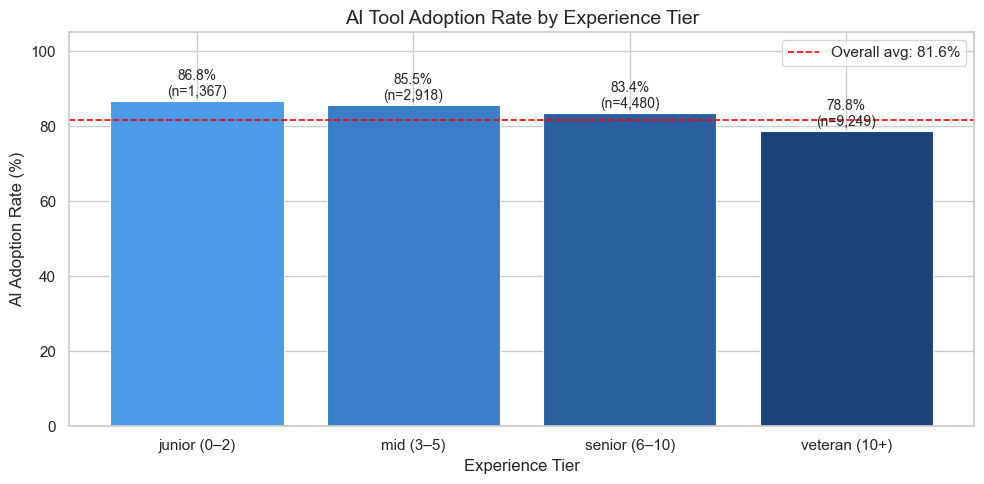

In [124]:
# Calculate AI adoption rate per experience tier
ai_by_exp = (
    df_expanded
    .groupby('ExperienceTier', observed=True)['UsesAI']
    .agg(
        total='count',
        ai_users='sum'
    )
    .assign(adoption_rate=lambda x: (x['ai_users'] / x['total']) * 100)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    ai_by_exp['ExperienceTier'],
    ai_by_exp['adoption_rate'],
    color=['#4C9BE8', '#3A7DC9', '#2A5FA0', '#1A4277'],  # gradient to show progression
    edgecolor='white',
    linewidth=0.8
)

# Annotate each bar with the adoption % and raw count
for bar, row in zip(bars, ai_by_exp.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{row.adoption_rate:.1f}%\n(n={row.total:,})",
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('AI Tool Adoption Rate by Experience Tier', fontsize=14)
ax.set_xlabel('Experience Tier')
ax.set_ylabel('AI Adoption Rate (%)')
ax.set_ylim(0, 105)
ax.axhline(
    df_expanded['UsesAI'].mean() * 100,
    color='red', linestyle='--', linewidth=1.2,
    label=f"Overall avg: {df_expanded['UsesAI'].mean()*100:.1f}%"
)
ax.legend()

plt.tight_layout()
plt.savefig('visuals/ai_adoption_by_experience.png', dpi=150, bbox_inches='tight')
plt.show()


### Salary Distribution by Experience Tier
- Does salary increase with seniority?
- This establishes whether experience correlates with salary — the second arm of the confound.

C:\Users\ingex\AppData\Local\Temp\ipykernel_20316\188696894.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


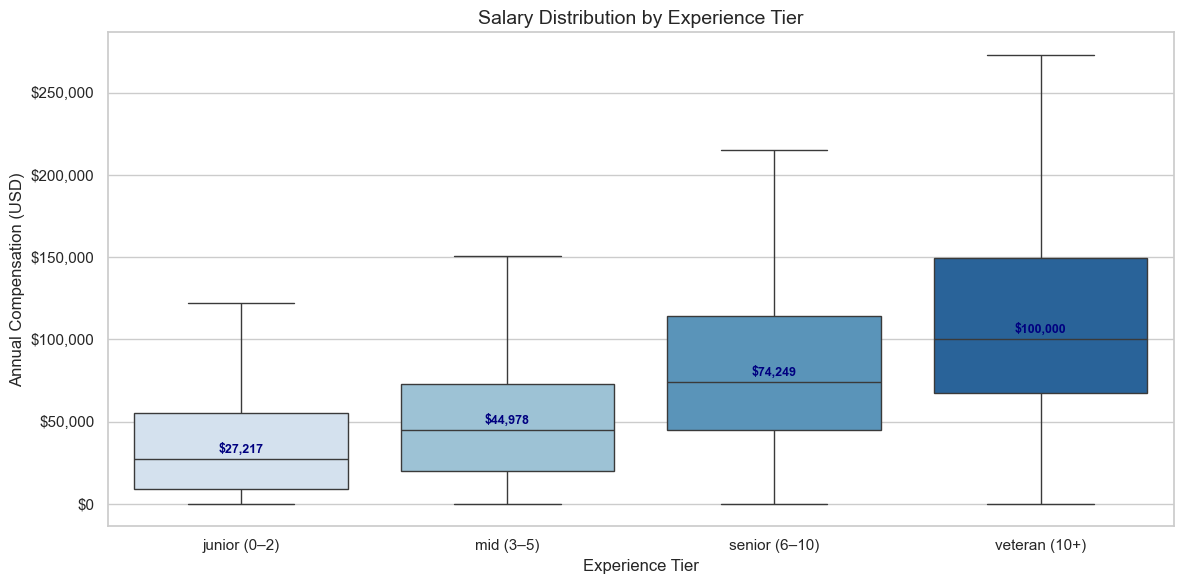

In [125]:
fig, ax = plt.subplots(figsize=(12, 6))

# Order tiers logically (not alphabetically)
tier_order = ['junior (0–2)', 'mid (3–5)', 'senior (6–10)', 'veteran (10+)']

sns.boxplot(
    data=df_expanded,
    x='ExperienceTier',
    y='ConvertedCompYearly',
    order=tier_order,
    palette='Blues',
    showfliers=False,  # hide extreme outliers so the box is readable
    ax=ax
)

# Overlay median labels above each box
medians = (
    df_expanded.groupby('ExperienceTier', observed=True)['ConvertedCompYearly']
    .median()
    .reindex(tier_order)
)
for i, (tier, med) in enumerate(medians.items()):
    ax.text(i, med + 2000, f'${med:,.0f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='navy')

ax.set_title('Salary Distribution by Experience Tier', fontsize=14)
ax.set_xlabel('Experience Tier')
ax.set_ylabel('Annual Compensation (USD)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.tight_layout()
plt.savefig('visuals/salary_by_experience.png', dpi=150, bbox_inches='tight')
plt.show()


### Salary by AI Usage - Controlled by Experience Tier (US Market)

- The global dataset masks the experience–salary relationship due to large USD salary differences across countries. To isolate the experience effect cleanly, this chart uses US respondents only as a methodological demonstration.

- The full model controls for this by including Region as a feature, allowing it to learn country-level salary baselines rather than filtering them out.

US subset: 3896 rows


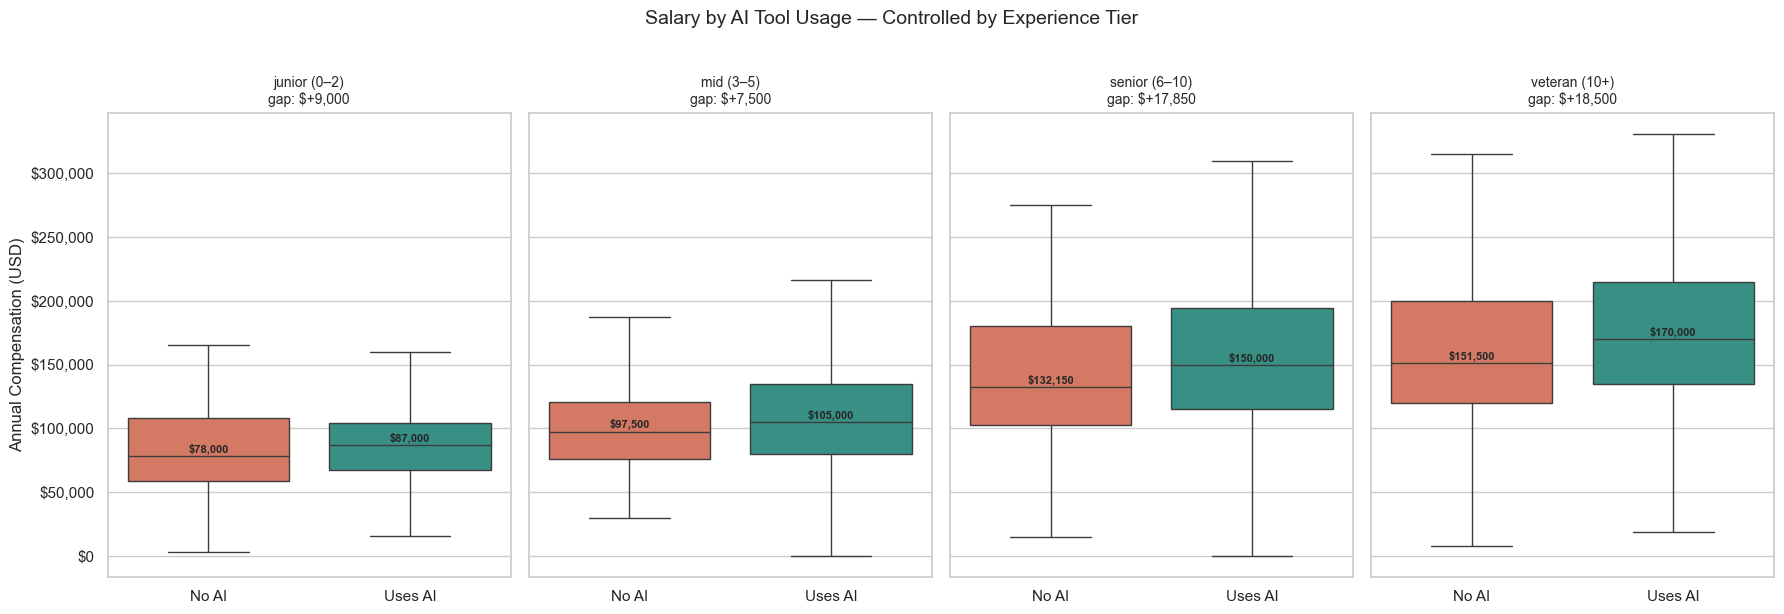

In [126]:
# US-only subset — isolates experience effect from country salary differences
df_us = df_expanded[df_expanded['Country'] == 'United States of America'].copy()
print(f"US subset: {len(df_us)} rows")

tier_order = ['junior (0–2)', 'mid (3–5)', 'senior (6–10)', 'veteran (10+)']
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)

for i, tier in enumerate(tier_order):
    ax = axes[i]
    subset = df_us[df_us['ExperienceTier'] == tier].copy()
    
    # Convert boolean to readable string — fixes the palette key error
    subset['AI Usage'] = subset['UsesAI'].map({True: 'Uses AI', False: 'No AI'})

    sns.boxplot(
        data=subset,
        x='AI Usage',
        y='ConvertedCompYearly',
        hue='AI Usage',
        order=['No AI', 'Uses AI'],
        palette={'Uses AI': '#2A9D8F', 'No AI': '#E76F51'},
        showfliers=False,
        legend=False,
        ax=ax
    )

    med_ai = subset[subset['UsesAI'] == True]['ConvertedCompYearly'].median()
    med_no_ai = subset[subset['UsesAI'] == False]['ConvertedCompYearly'].median()
    gap = med_ai - med_no_ai

    for j, uses_ai in enumerate([False, True]):
        group = subset[subset['UsesAI'] == uses_ai]['ConvertedCompYearly']
        if len(group) > 0:
            med = group.median()
            ax.text(j, med + 1500, f'${med:,.0f}',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_title(f'{tier}\ngap: ${gap:+,.0f}', fontsize=10)
    ax.set_xlabel('')
    if i == 0:
        ax.set_ylabel('Annual Compensation (USD)')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    else:
        ax.set_ylabel('')

fig.suptitle('Salary by AI Tool Usage — Controlled by Experience Tier', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('visuals/confound_check_ai_salary_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

### Salary by Country (Top 10 by Respondent Count)
- Country is a structural confounder — USD salary benchmarks vary dramatically by region.
- Developers in the US earn significantly more in USD terms for equivalent work.
- Country must be included as a model feature to avoid attributing geographic salary differences to other variables.

C:\Users\ingex\AppData\Local\Temp\ipykernel_20316\122019338.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ingex\AppData\Local\Temp\ipykernel_20316\122019338.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


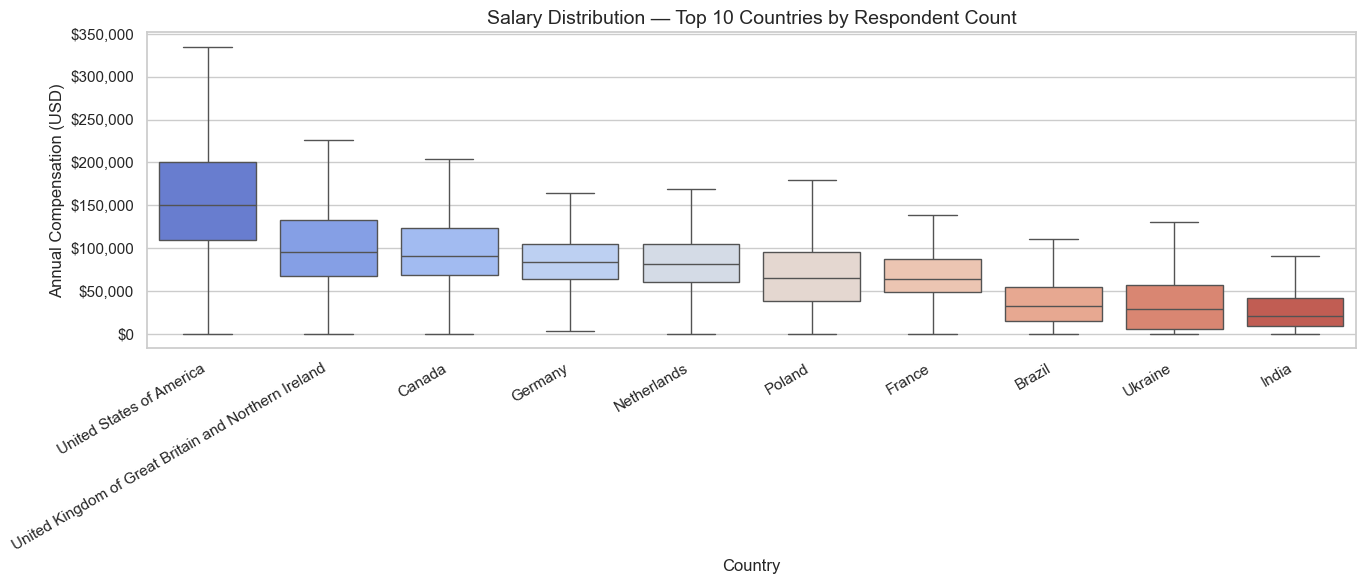

In [127]:
# Get top 10 countries by respondent count for readability
top_countries = (
    df_expanded['Country']
    .value_counts()
    .head(10)
    .index.tolist()
)

country_subset = df_expanded[df_expanded['Country'].isin(top_countries)]

# Sort by median salary for a clean chart
country_order = (
    country_subset.groupby('Country')['ConvertedCompYearly']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=country_subset,
    x='Country',
    y='ConvertedCompYearly',
    order=country_order,
    palette='coolwarm',
    showfliers=False,
    ax=ax
)

ax.set_title('Salary Distribution — Top 10 Countries by Respondent Count', fontsize=14)
ax.set_xlabel('Country')
ax.set_ylabel('Annual Compensation (USD)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('visuals/salary_by_country.png', dpi=150, bbox_inches='tight')
plt.show()


### Salary by Industry (Top 10 by Respondent Count)
- Industry is a structural confounder — USD salary benchmarks vary dramatically by region.
- Developers in the US earn significantly more in USD terms for equivalent work.
- Country must be included as a model feature to avoid attributing geographic salary differences to other variables.

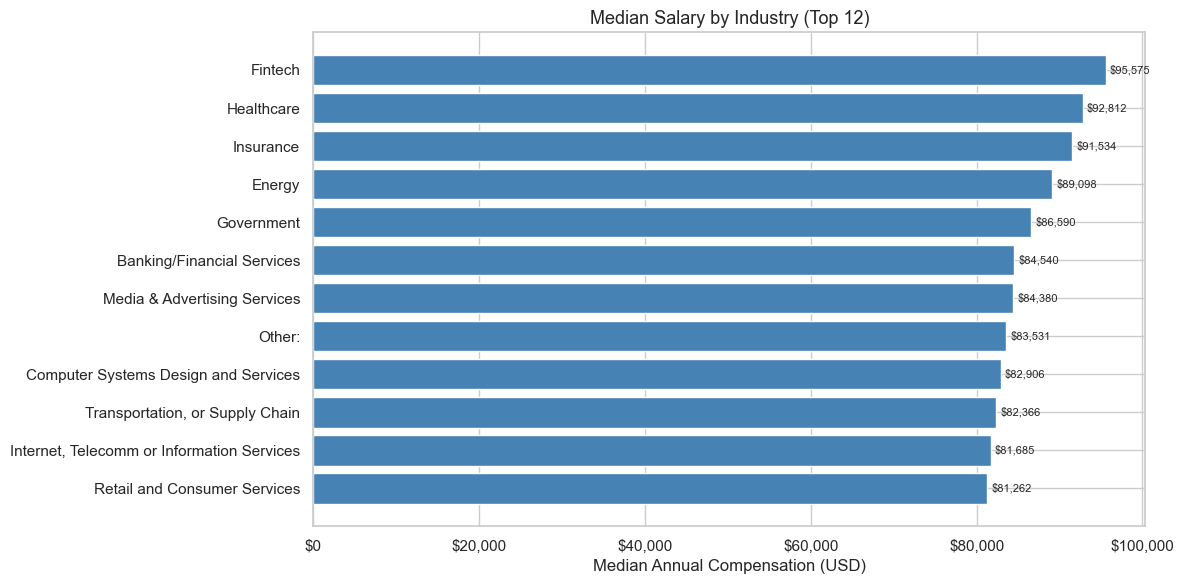

In [128]:
# --- Industry ---
# DevType multi-selects need the same treatment but Industry is single-select
industry_salary = (
    df_expanded[df_expanded['Industry'] != 'Unknown']
    .groupby('Industry')['ConvertedCompYearly']
    .agg(median='median', count='count')
    .query('count >= 100')
    .sort_values('median', ascending=True)
    .tail(12)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(industry_salary['Industry'], industry_salary['median'],
        color='steelblue', edgecolor='white')
for _, row in industry_salary.iterrows():
    ax.text(row['median'] + 500, industry_salary[industry_salary['Industry']==row['Industry']].index[0] % len(industry_salary),
            f"${row['median']:,.0f}", va='center', fontsize=8)
ax.set_title('Median Salary by Industry (Top 12)', fontsize=13)
ax.set_xlabel('Median Annual Compensation (USD)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('visuals/salary_by_industry.png', dpi=150, bbox_inches='tight')
plt.show()

### Median Salary by Developer Type

- DevType acts as a seniority proxy — Engineering Managers, SREs, and Cloud architects sit at the top of the salary distribution by role definition, not skill alone.
- Included as a model feature to avoid role-level salary differences distorting the AI signal.

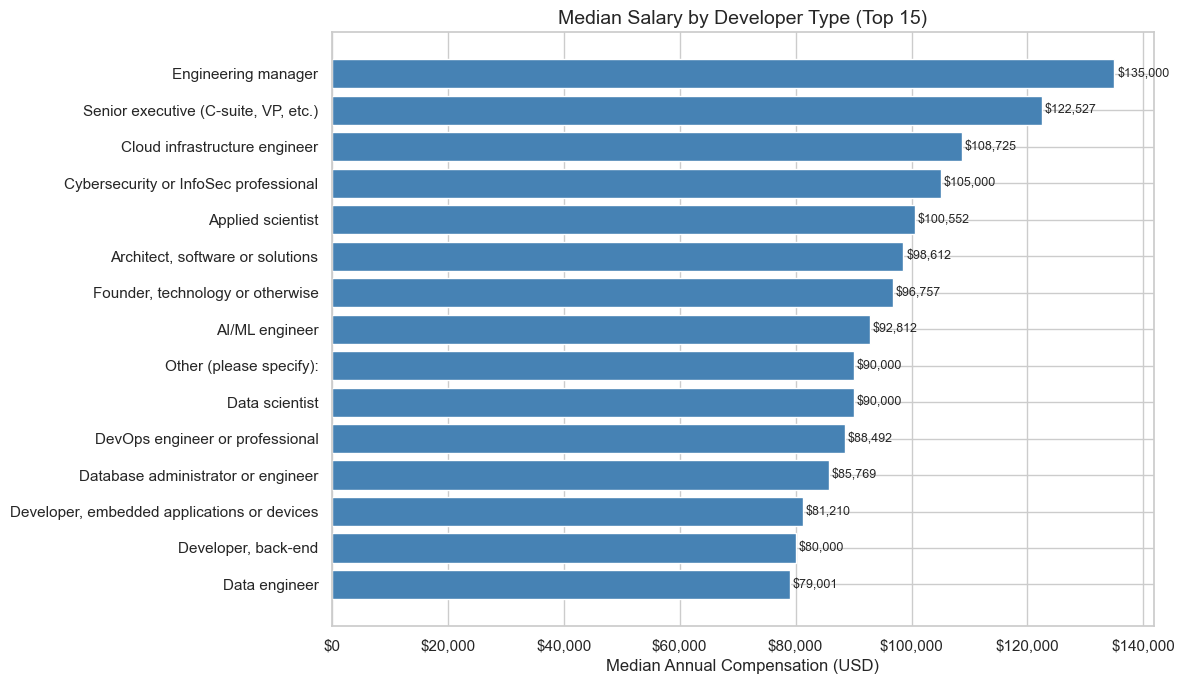

In [129]:
# Compute median salary per DevType, filter out 'Unknown', take top 15 for readability
devtype_salary = (
    df_expanded[df_expanded['DevType'] != 'Unknown']
    .groupby('DevType')['ConvertedCompYearly']
    .agg(median='median', count='count')
    .query('count >= 50')          # minimum 50 respondents per role for reliability
    .sort_values('median', ascending=True)
    .tail(15)                      # top 15 highest-paid roles
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    devtype_salary['DevType'],
    devtype_salary['median'],
    color='steelblue',
    edgecolor='white'
)

# Annotate each bar with the median value
for bar, row in zip(bars, devtype_salary.itertuples()):
    ax.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height() / 2,
        f'${row.median:,.0f}',
        va='center', fontsize=9
    )

ax.set_title('Median Salary by Developer Type (Top 15)', fontsize=14)
ax.set_xlabel('Median Annual Compensation (USD)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('visuals/salary_by_devtype.png', dpi=150, bbox_inches='tight')
plt.show()


### Education Level — Salary and AI Adoption

- Checking whether education level drives salary independently of experience.
- If the salary spread is small, EdLevel is a weak confounder. If significant, it must be included as a model feature.

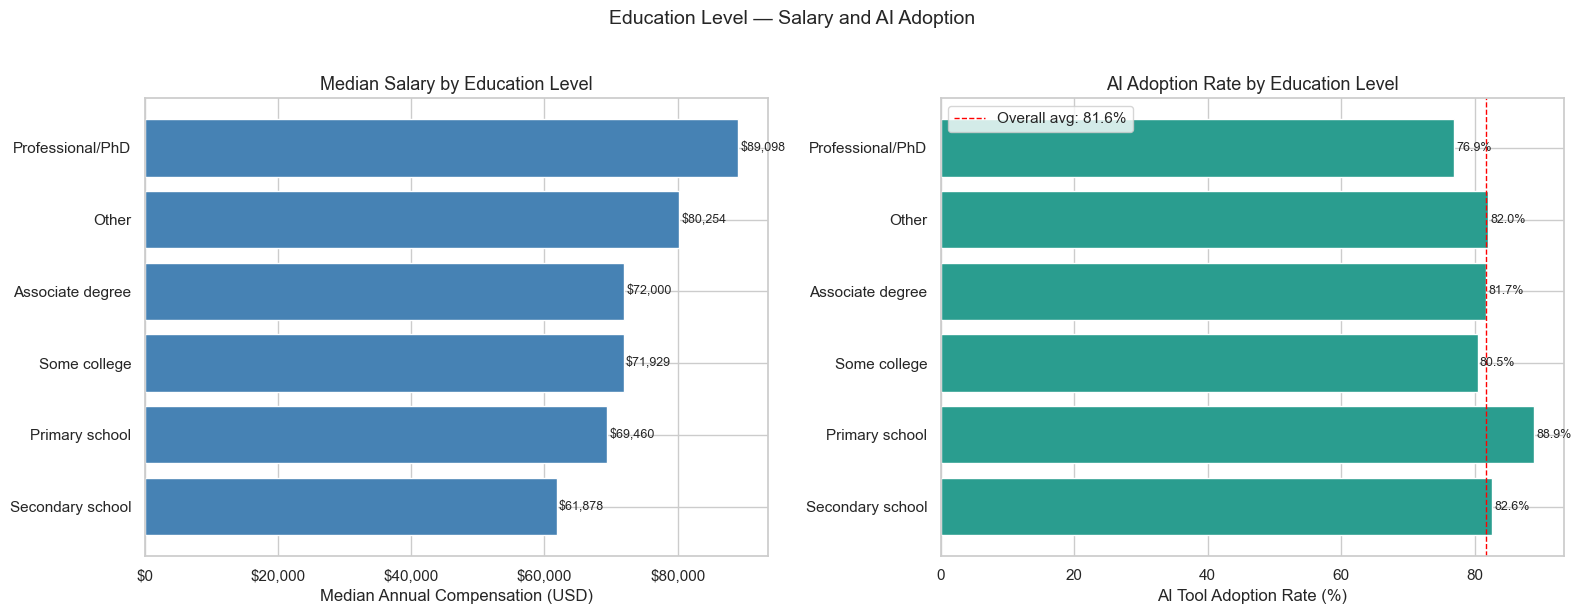

In [130]:
# Clean up EdLevel labels for readability
edlevel_label_map = {
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)": "Bachelor's",
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": "Master's",
    "Some college/university study without earning a degree": "Some college",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "Secondary school",
    "Associate degree (A.A., A.S., etc.)": "Associate degree",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "Professional/PhD",
    "Primary/elementary school": "Primary school",
    "Something else": "Other",
    "Unknown": "Unknown"
}
df_expanded['EdLevelClean'] = df_expanded['EdLevel'].map(edlevel_label_map).fillna('Other')

# Remove unknown for cleaner chart
ed_data = df_expanded[df_expanded['EdLevelClean'] != 'Unknown']

# Compute median salary and AI adoption per level
ed_summary = (
    ed_data.groupby('EdLevelClean')
    .agg(
        median_salary=('ConvertedCompYearly', 'median'),
        ai_adoption=('UsesAI', 'mean'),
        count=('ConvertedCompYearly', 'count')
    )
    .query('count >= 50')
    .assign(ai_adoption_pct=lambda x: x['ai_adoption'] * 100)
    .sort_values('median_salary', ascending=True)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: median salary by EdLevel ---
bars = axes[0].barh(
    ed_summary['EdLevelClean'],
    ed_summary['median_salary'],
    color='steelblue',
    edgecolor='white'
)
for bar, row in zip(bars, ed_summary.itertuples()):
    axes[0].text(
        bar.get_width() + 300,
        bar.get_y() + bar.get_height() / 2,
        f'${row.median_salary:,.0f}',
        va='center', fontsize=9
    )
axes[0].set_title('Median Salary by Education Level', fontsize=13)
axes[0].set_xlabel('Median Annual Compensation (USD)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# --- Right: AI adoption by EdLevel ---
bars2 = axes[1].barh(
    ed_summary['EdLevelClean'],
    ed_summary['ai_adoption_pct'],
    color='#2A9D8F',
    edgecolor='white'
)
for bar, row in zip(bars2, ed_summary.itertuples()):
    axes[1].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{row.ai_adoption_pct:.1f}%',
        va='center', fontsize=9
    )
axes[1].set_title('AI Adoption Rate by Education Level', fontsize=13)
axes[1].set_xlabel('AI Tool Adoption Rate (%)')
axes[1].axvline(
    df_expanded['UsesAI'].mean() * 100,
    color='red', linestyle='--', linewidth=1,
    label=f"Overall avg: {df_expanded['UsesAI'].mean()*100:.1f}%"
)
axes[1].legend()

fig.suptitle('Education Level — Salary and AI Adoption', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('visuals/edlevel_salary_and_ai.png', dpi=150, bbox_inches='tight')
plt.show()

### Drop EdLevel from Features

In [131]:
# Drop EdLevel column as requested
df_expanded = df_expanded.drop(columns=['EdLevel'])
df_expanded = df_expanded.drop(columns=['EdLevelClean'])

### Tech Stack — Salary Premium vs AI Adoption Rate

- Each point is a technology. Position on the x-axis shows salary premium over non-users.
- Position on the y-axis shows what % of that tool's users also use AI tools.
- Point size is proportional to the number of users.

- Tools in the top-right quadrant: high salary AND high AI adoption.
- Tools in the top-left quadrant: high AI adoption but no salary premium (the paradox group).

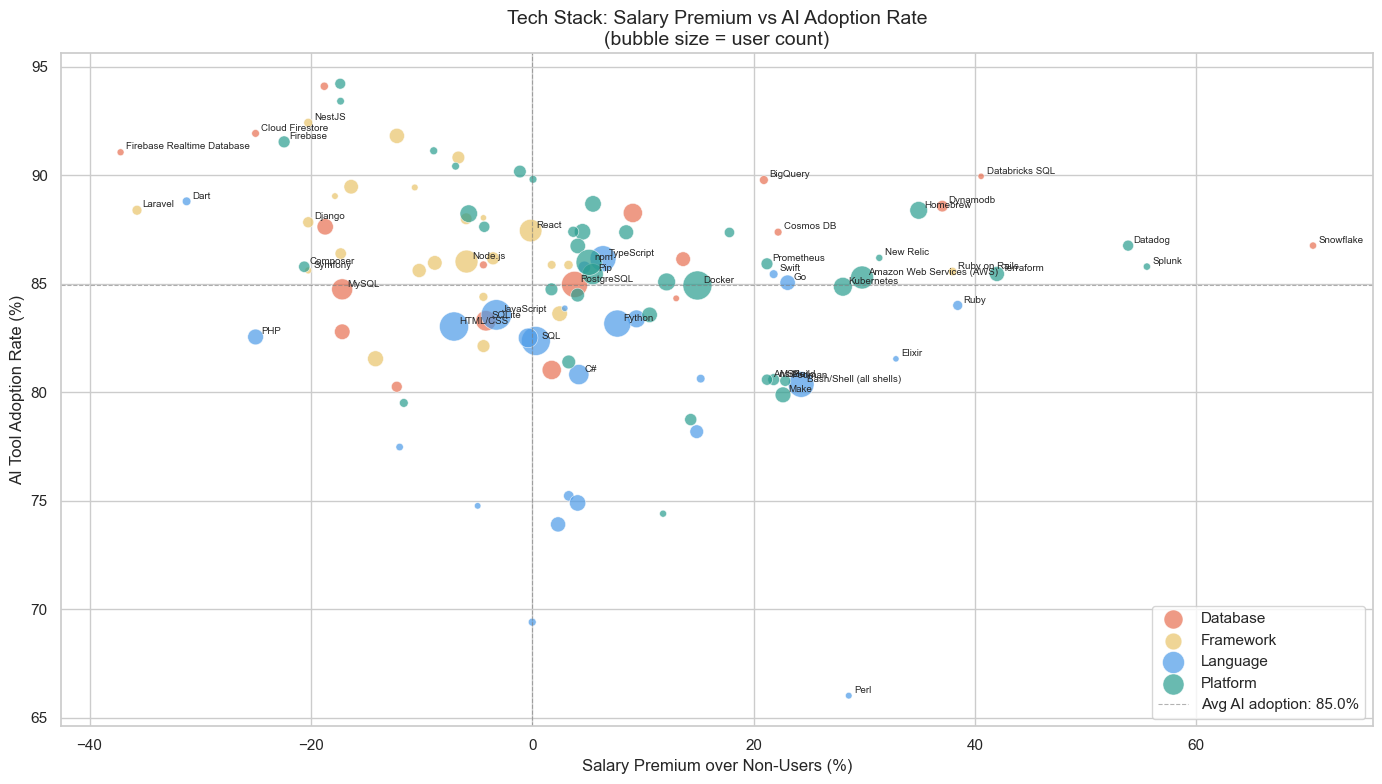

In [132]:
import pandas as pd

# Combine all four summary tables into one for the scatter
all_summaries = pd.concat([
    languagehaveworkedwith_summary_df.assign(category='Language'),
    databasehaveworkedwith_summary_df.assign(category='Database'),
    platformhaveworkedwith_summary_df.assign(category='Platform'),
    webframehaveworkedwith_summary_df.assign(category='Framework')
], ignore_index=True)

# Use only tools that passed the 500-user threshold (already filtered in summary dfs)
fig, ax = plt.subplots(figsize=(14, 8))

category_colors = {
    'Language': '#4C9BE8',
    'Database': '#E76F51',
    'Platform': '#2A9D8F',
    'Framework': '#E9C46A'
}

for category, group in all_summaries.groupby('category'):
    ax.scatter(
        group['salary_premium_%'],
        group['tool_ai_adoption_%'],
        s=group['user_count'] / 25,          # size proportional to user count
        color=category_colors[category],
        alpha=0.7,
        label=category,
        edgecolors='white',
        linewidth=0.5
    )
    # Label only the most prominent tools (large premium or large user count)
    for _, row in group.iterrows():
        if abs(row['salary_premium_%']) > 20 or row['user_count'] > 5000:
            ax.annotate(
                row['tool'],
                (row['salary_premium_%'], row['tool_ai_adoption_%']),
                fontsize=7,
                xytext=(4, 2),
                textcoords='offset points'
            )

# Reference lines
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(
    all_summaries['tool_ai_adoption_%'].mean(),
    color='grey', linestyle='--', linewidth=0.8, alpha=0.6,
    label=f"Avg AI adoption: {all_summaries['tool_ai_adoption_%'].mean():.1f}%"
)

ax.set_title('Tech Stack: Salary Premium vs AI Adoption Rate\n(bubble size = user count)', fontsize=14)
ax.set_xlabel('Salary Premium over Non-Users (%)')
ax.set_ylabel('AI Tool Adoption Rate (%)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('visuals/tech_stack_premium_vs_ai_adoption.png', dpi=150, bbox_inches='tight')
plt.show()


### Feature Selection Summary — Top Tools by Salary Premium

- Tools that passed the ±15% salary premium threshold. These are the columns carried forward into the machine learning model.
- Positive bars = salary premium over non-users. Negative bars = salary penalty.

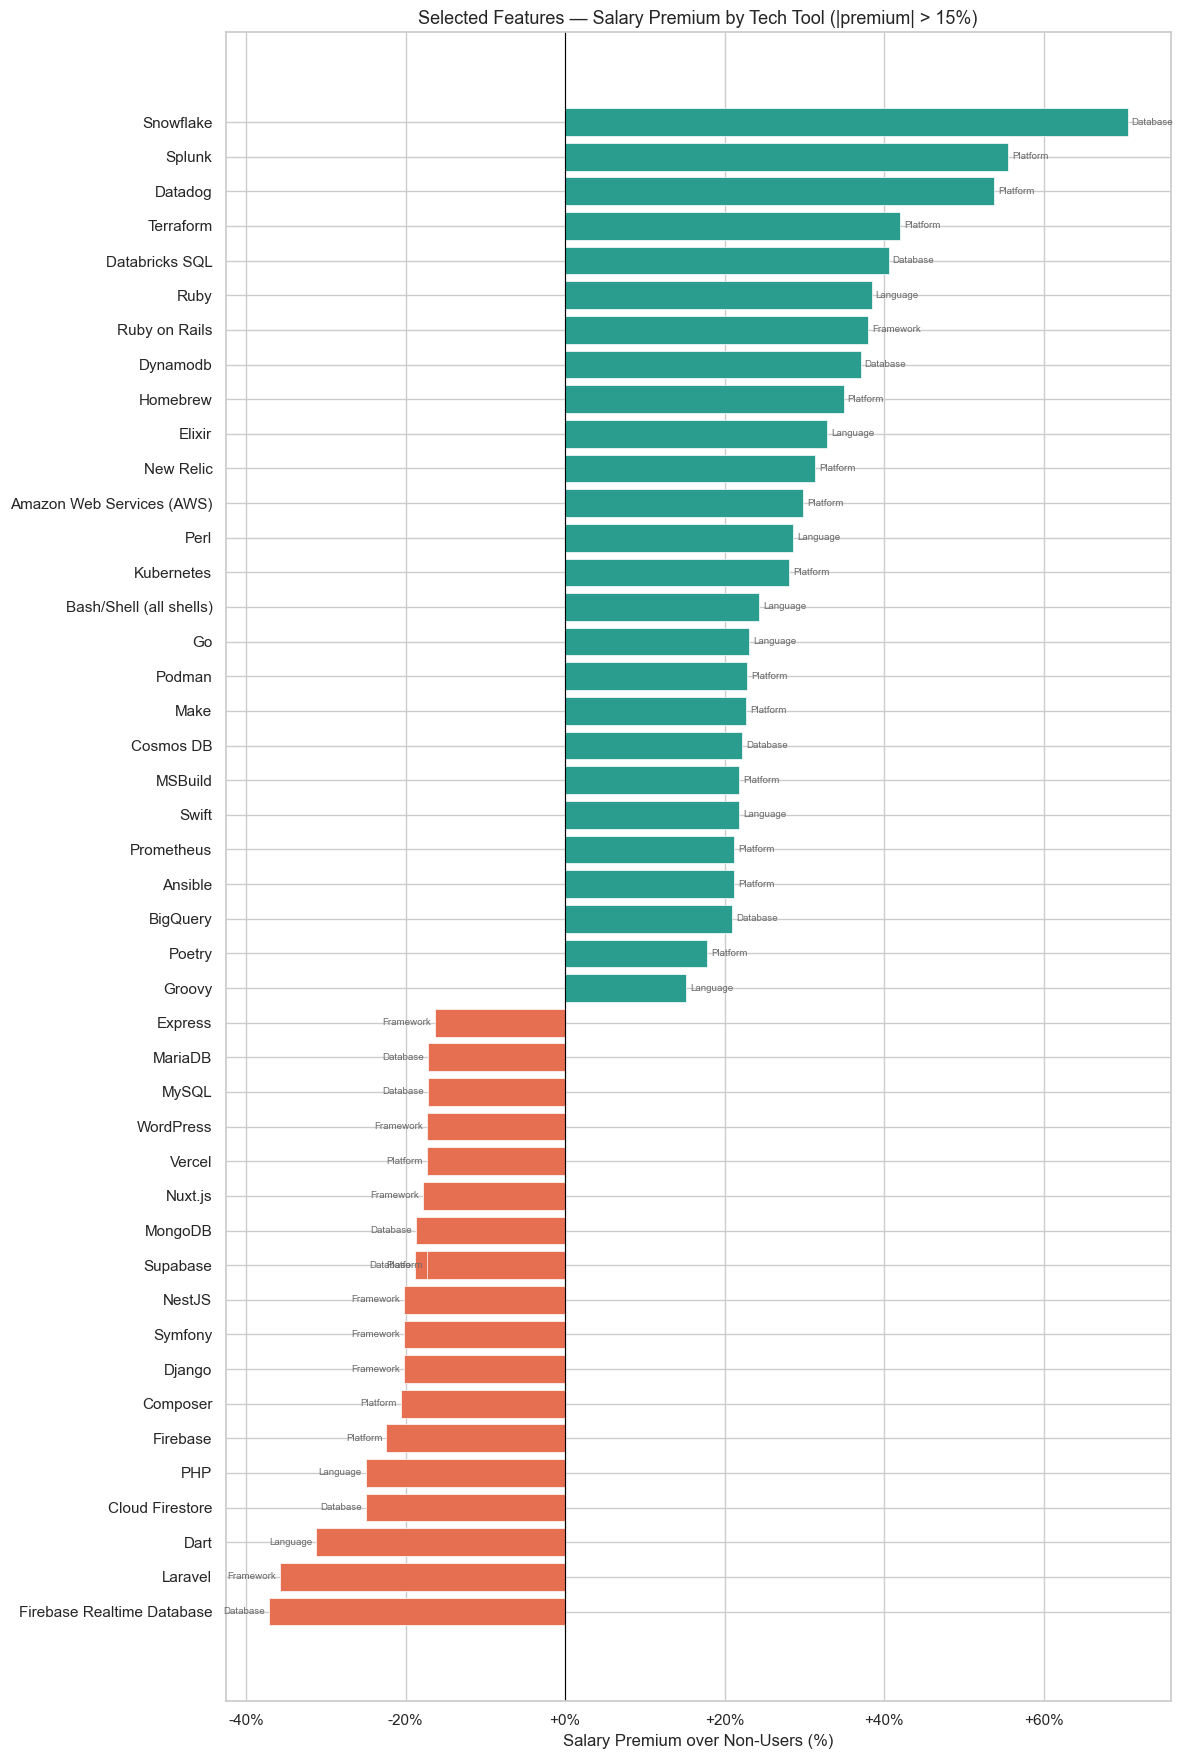


Total features selected for model: 45
                      tool  category  salary_premium_%  user_count
Firebase Realtime Database  Database        -37.197500         627
                   Laravel Framework        -35.713582        1241
                      Dart  Language        -31.230625         956
           Cloud Firestore  Database        -25.000000         769
                       PHP  Language        -24.999694        3216
                  Firebase  Platform        -22.419481        1822
                  Composer  Platform        -20.600276        1654
                    Django Framework        -20.240000        1571
                   Symfony Framework        -20.240000         619
                    NestJS Framework        -20.240000        1017
                  Supabase  Database        -18.790000         866
                   MongoDB  Database        -18.708287        3453
                   Nuxt.js Framework        -17.826516         557
                    Ver

In [133]:
# Filter to only tools with |premium| > 15%
selected_tools = all_summaries[all_summaries['salary_premium_%'].abs() > 15].copy()
selected_tools = selected_tools.sort_values('salary_premium_%', ascending=True)

# Assign bar colours by positive/negative premium
bar_colors = ['#E76F51' if x < 0 else '#2A9D8F' for x in selected_tools['salary_premium_%']]

fig, ax = plt.subplots(figsize=(12, len(selected_tools) * 0.35 + 2))

bars = ax.barh(
    selected_tools['tool'],
    selected_tools['salary_premium_%'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5
)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Selected Features — Salary Premium by Tech Tool (|premium| > 15%)', fontsize=13)
ax.set_xlabel('Salary Premium over Non-Users (%)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0f}%'))

# Add category label on each bar
for bar, row in zip(bars, selected_tools.itertuples()):
    x_pos = bar.get_width()
    offset = 0.5 if x_pos >= 0 else -0.5
    ha = 'left' if x_pos >= 0 else 'right'
    ax.text(x_pos + offset,
            bar.get_y() + bar.get_height() / 2,
            row.category,
            va='center', ha=ha, fontsize=7, color='dimgray')

plt.tight_layout()
plt.savefig('visuals/feature_selection_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal features selected for model: {len(selected_tools)}")
print(selected_tools[['tool', 'category', 'salary_premium_%', 'user_count']].to_string(index=False))

### Encode Region as a Feature

In [134]:
# All values in Country and number of users per country
country_counts = df_filtered['Country'].value_counts()

print("All possible values for 'Country' with counts:")
for country, count in country_counts.items():
    print(f"- {country}: {count}")

All possible values for 'Country' with counts:
- United States of America: 4788
- Germany: 1907
- United Kingdom of Great Britain and Northern Ireland: 1352
- India: 928
- France: 911
- Canada: 810
- Ukraine: 656
- Brazil: 576
- Netherlands: 566
- Italy: 538
- Poland: 529
- Spain: 515
- Australia: 505
- Sweden: 426
- Switzerland: 379
- Czech Republic: 330
- Austria: 251
- Denmark: 200
- Portugal: 195
- Belgium: 191
- Romania: 189
- Finland: 182
- Turkey: 167
- Norway: 167
- South Africa: 165
- Mexico: 163
- New Zealand: 162
- Greece: 161
- Hungary: 156
- Israel: 153
- Bulgaria: 148
- Ireland: 143
- Argentina: 142
- Pakistan: 119
- Russian Federation: 119
- Colombia: 116
- Japan: 114
- China: 104
- Bangladesh: 103
- Serbia: 100
- Slovakia: 98
- Nigeria: 84
- Chile: 82
- Croatia: 75
- Philippines: 74
- Indonesia: 71
- Iran, Islamic Republic of...: 67
- Lithuania: 62
- Taiwan: 60
- Singapore: 59
- Slovenia: 58
- Kenya: 57
- Egypt: 53
- Estonia: 50
- Sri Lanka: 50
- Viet Nam: 49
- Thailand

In [135]:
region_map = {
    # North America
    'United States of America': 'North America',
    'Canada': 'North America',

    # Western Europe
    'United Kingdom of Great Britain and Northern Ireland': 'Western Europe',
    'Germany': 'Western Europe',
    'France': 'Western Europe',
    'Netherlands': 'Western Europe',
    'Sweden': 'Western Europe',
    'Switzerland': 'Western Europe',
    'Austria': 'Western Europe',
    'Denmark': 'Western Europe',
    'Belgium': 'Western Europe',
    'Finland': 'Western Europe',
    'Norway': 'Western Europe',
    'Ireland': 'Western Europe',
    'Luxembourg': 'Western Europe',

    # Southern Europe (optional split, or merge into Western Europe)
    'Italy': 'Western Europe',
    'Spain': 'Western Europe',
    'Portugal': 'Western Europe',
    'Greece': 'Western Europe',

    # Eastern Europe
    'Poland': 'Eastern Europe',
    'Ukraine': 'Eastern Europe',
    'Czech Republic': 'Eastern Europe',
    'Romania': 'Eastern Europe',
    'Hungary': 'Eastern Europe',
    'Bulgaria': 'Eastern Europe',
    'Slovakia': 'Eastern Europe',
    'Croatia': 'Eastern Europe',
    'Serbia': 'Eastern Europe',

    # Latin America
    'Brazil': 'Latin America',
    'Argentina': 'Latin America',
    'Mexico': 'Latin America',
    'Colombia': 'Latin America',
    'Chile': 'Latin America',
    'Peru': 'Latin America',
    'Uruguay': 'Latin America',
    'Venezuela, Bolivarian Republic of...': 'Latin America',

    # Africa
    'South Africa': 'Sub-Saharan Africa',
    'Nigeria': 'Sub-Saharan Africa',
    'Kenya': 'Sub-Saharan Africa',
    'Ghana': 'Sub-Saharan Africa',
    'Egypt': 'Middle East & North Africa',
    'Morocco': 'Middle East & North Africa',
    'Tunisia': 'Middle East & North Africa',

    # Middle East
    'Israel': 'Middle East & North Africa',
    'United Arab Emirates': 'Middle East & North Africa',
    'Saudi Arabia': 'Middle East & North Africa',
    'Iran, Islamic Republic of...': 'Middle East & North Africa',

    # South Asia
    'India': 'South Asia',
    'Pakistan': 'South Asia',
    'Bangladesh': 'South Asia',
    'Sri Lanka': 'South Asia',
    'Nepal': 'South Asia',

    # East Asia
    'China': 'East Asia',
    'Japan': 'East Asia',
    'South Korea': 'East Asia',
    'Republic of Korea': 'East Asia',
    'Taiwan': 'East Asia',
    'Hong Kong (S.A.R.)': 'East Asia',

    # Southeast Asia
    'Indonesia': 'Southeast Asia',
    'Philippines': 'Southeast Asia',
    'Thailand': 'Southeast Asia',
    'Malaysia': 'Southeast Asia',
    'Viet Nam': 'Southeast Asia',
    'Singapore': 'Southeast Asia',

    # Oceania
    'Australia': 'Oceania',
    'New Zealand': 'Oceania',
}

df_expanded['Region'] = df_expanded['Country'].map(region_map).fillna('Other')

# Check what's unmapped
unmapped = df_expanded[~df_expanded['Country'].isin(region_map.keys())]['Country'].value_counts()

print(unmapped.head(20))

Country
Turkey                    143
Russian Federation        101
Lithuania                  54
Slovenia                   52
Estonia                    45
Latvia                     35
Georgia                    28
Guatemala                  23
Ecuador                    20
Cyprus                     18
Jordan                     17
Dominican Republic         16
Bosnia and Herzegovina     16
Costa Rica                 16
Kazakhstan                 15
Malta                      14
Belarus                    14
Bolivia                    11
Armenia                    10
Montenegro                  9
Name: count, dtype: int64


In [136]:
# Initial region map — extended below to cover additional countries found via unmapped check

region_map.update({
    # Eastern Europe / Post-Soviet / Balkans
    'Russian Federation': 'Eastern Europe',
    'Lithuania': 'Eastern Europe',
    'Slovenia': 'Eastern Europe',
    'Estonia': 'Eastern Europe',
    'Latvia': 'Eastern Europe',
    'Georgia': 'Eastern Europe',
    'Bosnia and Herzegovina': 'Eastern Europe',
    'Belarus': 'Eastern Europe',
    'Armenia': 'Eastern Europe',
    'Montenegro': 'Eastern Europe',

    # Middle East & nearby
    'Turkey': 'Middle East & North Africa',
    'Jordan': 'Middle East & North Africa',
    'Cyprus': 'Middle East & North Africa',

    # Central Asia (group with Eastern Europe OR keep separate if you want later)
    'Kazakhstan': 'Eastern Europe',

    # Latin America
    'Guatemala': 'Latin America',
    'Ecuador': 'Latin America',
    'Dominican Republic': 'Latin America',
    'Costa Rica': 'Latin America',
    'Bolivia': 'Latin America',

    # Western Europe (small but high-income)
    'Malta': 'Western Europe',
})

In [137]:
df_expanded['Region'] = df_expanded['Country'].map(region_map).fillna('Other')

print(df_expanded['Region'].value_counts(normalize=True))

Region
Western Europe                0.380759
North America                 0.254080
Eastern Europe                0.130121
South Asia                    0.059620
Latin America                 0.058788
Oceania                       0.031420
Middle East & North Africa    0.027257
East Asia                     0.015710
Southeast Asia                0.015266
Other                         0.013989
Sub-Saharan Africa            0.012990
Name: proportion, dtype: float64


### Build Final Modelling Features

In [138]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# ── Step 1: Fix UsesAI to 0/1 ───────────────────────────────────────
df_expanded['UsesAI'] = df_expanded['UsesAI'].astype(int)

# ── Step 2: Ordinal encode ExperienceTier (genuinely ordered) ────────
tier_map = {'junior (0–2)': 0, 'mid (3–5)': 1, 'senior (6–10)': 2, 'veteran (10+)': 3}
df_expanded['ExperienceTier_encoded'] = df_expanded['ExperienceTier'].map(tier_map)

# ── Step 3: OHE nominal categoricals (no implied order) ──────────────
df_expanded = pd.get_dummies(
    df_expanded,
    columns=['Region', 'DevType', 'Industry'],
    drop_first=True,   # avoids dummy variable trap for linear regression
    dtype=int          # 0/1 integers not booleans
)

ohe_cols = [c for c in df_expanded.columns
            if c.startswith(('Region_', 'DevType_', 'Industry_'))]
print(f"OHE columns created: {len(ohe_cols)}")

# ── Step 4: Match 45 selected tools to their df_expanded column names ─
prefix_map = {
    'Language':  'LanguageHaveWorkedWith_',
    'Database':  'DatabaseHaveWorkedWith_',
    'Platform':  'PlatformHaveWorkedWith_',
    'Framework': 'WebframeHaveWorkedWith_'
}

selected_tool_cols = []
for _, row in selected_tools.iterrows():
    col = f"{prefix_map[row['category']]}{row['tool']}"
    if col in df_expanded.columns:
        selected_tool_cols.append(col)

print(f"Tool columns matched: {len(selected_tool_cols)} of {len(selected_tools)}")

# ── Step 5: Build final model dataframe ───────────────────────────────
core_features = [
    'WorkExp',        # continuous experience — more signal than binned tier
    'UsesAI',         # the key variable under investigation
    'log_salary',     # regression target
    'ConvertedCompYearly',  # kept for reference / classifier use
]

model_cols = core_features + ohe_cols + selected_tool_cols
df_model = df_expanded[model_cols].copy()

print(f"\nFinal model dataset: {df_model.shape}")
print(f"  Core features:      {len(core_features)}")
print(f"  OHE features:       {len(ohe_cols)}")
print(f"  Tech tool features: {len(selected_tool_cols)}")
display(df_model.head(5))

OHE columns created: 56
Tool columns matched: 45 of 45

Final model dataset: (18014, 105)
  Core features:      4
  OHE features:       56
  Tech tool features: 45


,WorkExp,UsesAI,log_salary,ConvertedCompYearly,Region_Eastern Europe,Region_Latin America,Region_Middle East & North Africa,Region_North America,Region_Oceania,Region_Other,Region_South Asia,Region_Southeast Asia,Region_Sub-Saharan Africa,Region_Western Europe,DevType_Academic researcher,DevType_Applied scientist,"DevType_Architect, software or solutions",DevType_Cloud infrastructure engineer,DevType_Cybersecurity or InfoSec professional,DevType_Data engineer,DevType_Data or business analyst,DevType_Data scientist,DevType_Database administrator or engineer,DevType_DevOps engineer or professional,"DevType_Developer, AI apps or physical AI","DevType_Developer, QA or test","DevType_Developer, back-end","DevType_Developer, desktop or enterprise applications","DevType_Developer, embedded applications or devices","DevType_Developer, front-end","DevType_Developer, full-stack","DevType_Developer, game or graphics","DevType_Developer, mobile",DevType_Engineering manager,DevType_Financial analyst or engineer,"DevType_Founder, technology or otherwise",DevType_Other (please specify):,DevType_Product manager,DevType_Project manager,DevType_Retired,"DevType_Senior executive (C-suite, VP, etc.)",DevType_Student,DevType_Support engineer or analyst,DevType_System administrator,"DevType_UX, Research Ops or UI design professional",Industry_Computer Systems Design and Services,Industry_Energy,Industry_Fintech,Industry_Government,Industry_Healthcare,Industry_Higher Education,Industry_Insurance,"Industry_Internet, Telecomm or Information Services",Industry_Manufacturing,Industry_Media & Advertising Services,Industry_Other:,Industry_Retail and Consumer Services,Industry_Software Development,"Industry_Transportation, or Supply Chain",Industry_Unknown,DatabaseHaveWorkedWith_Firebase Realtime Database,WebframeHaveWorkedWith_Laravel,LanguageHaveWorkedWith_Dart,DatabaseHaveWorkedWith_Cloud Firestore,LanguageHaveWorkedWith_PHP,PlatformHaveWorkedWith_Firebase,PlatformHaveWorkedWith_Composer,WebframeHaveWorkedWith_Django,WebframeHaveWorkedWith_Symfony,WebframeHaveWorkedWith_NestJS,DatabaseHaveWorkedWith_Supabase,DatabaseHaveWorkedWith_MongoDB,WebframeHaveWorkedWith_Nuxt.js,PlatformHaveWorkedWith_Vercel,PlatformHaveWorkedWith_Supabase,WebframeHaveWorkedWith_WordPress,DatabaseHaveWorkedWith_MySQL,DatabaseHaveWorkedWith_MariaDB,WebframeHaveWorkedWith_Express,LanguageHaveWorkedWith_Groovy,PlatformHaveWorkedWith_Poetry,DatabaseHaveWorkedWith_BigQuery,PlatformHaveWorkedWith_Ansible,PlatformHaveWorkedWith_Prometheus,LanguageHaveWorkedWith_Swift,PlatformHaveWorkedWith_MSBuild,DatabaseHaveWorkedWith_Cosmos DB,PlatformHaveWorkedWith_Make,PlatformHaveWorkedWith_Podman,LanguageHaveWorkedWith_Go,LanguageHaveWorkedWith_Bash/Shell (all shells),PlatformHaveWorkedWith_Kubernetes,LanguageHaveWorkedWith_Perl,PlatformHaveWorkedWith_Amazon Web Services (AWS),PlatformHaveWorkedWith_New Relic,LanguageHaveWorkedWith_Elixir,PlatformHaveWorkedWith_Homebrew,DatabaseHaveWorkedWith_Dynamodb,WebframeHaveWorkedWith_Ruby on Rails,LanguageHaveWorkedWith_Ruby,DatabaseHaveWorkedWith_Databricks SQL,PlatformHaveWorkedWith_Terraform,PlatformHaveWorkedWith_Datadog,PlatformHaveWorkedWith_Splunk,DatabaseHaveWorkedWith_Snowflake
0,8,1,11.022833,61256.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,2,1,11.556119,104413.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0,1,1,0,0
2,10,1,10.879216,53061.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,4,1,10.496759,36197.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

## Export Dataset for Modelling

In [140]:
# Export cleaned, feature-engineered dataset for modelling
output_path = 'df_model1_cleaned.csv'
df_model.to_csv(output_path, index=False)
print(f"Exported: {len(df_model)} rows × {len(df_model.columns)} columns")
print(f"Saved to: {output_path}")

Exported: 18014 rows × 105 columns
Saved to: df_model1_cleaned.csv
